# Imports

In [44]:
from jax import config
config.update("jax_enable_x64", True)


import pulseseq
from pulseseq.sequencing.waveform import AnalogPulse, Apodization, Shape, DigitalPulse, DigitalType, CompositeWaveform
from qcontrol.snv.particle import (
    SnVParticle,
    SnVDifferentiableParams,
    SnVNonDiffParams,
    SnVControlState,
    SnVDistribution,
    make_batched_helper,
)
import qcontrol.snv.particle_helpers as ph
import qcontrol.snv.hamiltonian_jqt as qh_jqt
from qcontrol.snv.jqt_ext import sesolve_components, mesolve_components
import qcontrol.snv.parameters as params
from qcontrol.snv.parameters import HyperfineNeighbor
import qcontrol.snv.pulseseq_interconnect
from qcontrol.snv.pulseseq_interconnect import stack_waveforms, make_analog_pulse_time_array, make_composite_waveform_time_array, synthesize_analog_pulse, synthesize_composite_waveform
import numpy as np
import jax.numpy as jnp
from matplotlib import pyplot as plt
from scipy.constants import c
from typing import NamedTuple, Any, Dict, Mapping
from abc import ABC, abstractmethod
from datetime import datetime
import jax
import jaxquantum as jqt
from diffrax import SaveAt



from typing import Callable
import time

# SnV Particle

`testing.ipynb` built one `SnV120Distribution` of `N` identical particles
(varying only `dipole_crystal_axis_idx`) and exercised it through its batched,
index-based API (`dist.method(idx=...)`). The `particle`/`particle_helpers`
modules instead represent *one* particle as an `SnVParticle` pytree and expose
plain functions `particle_helpers.method(particle, control_state, ...)`.

Two further differences follow directly from `particle_helpers.py`'s module
docstring:

- The two optimization targets (`B_target`, `target_dipole_operator`) are no
  longer stored on the particle/constants. They are explicit arguments to
  `get_B_settings`, `get_waveplate_angles`, and `get_optimal_control_state`
  only.
- Every other helper takes an explicit `SnVControlState` (no more
  `control_state=None` "use this member's own optimal controls" fallback) —
  call `get_optimal_control_state` yourself first, then pass its result
  around.

In [45]:
# -----------------------------------------------------------------------
# Quantities that used to live on the shared `SnVConstants`.
#
# `laser_frequency`, the lattice orientations, `nominal_magnet_axes`, and
# `sampling_rate` are now per-particle fields on `SnVNonDiffParams` (so that a
# batch of particles remains a plain pytree under `jax.vmap`), but every
# particle below is given the same value, exactly like the old shared
# `SnVConstants` did.
#
# `B_target` and `target_dipole_operator` are no longer stored at all; they
# are supplied explicitly wherever a control state must be optimized.
B_target = jnp.asarray([0.0, .5, 1.4 / 0.85])                    # (x, y, z) target electron-Zeeman vector in the dipole frame, GHz
target_dipole_operator = jnp.asarray([0.0, 0.0, 1.0])              # (x, y, z) target optical dipole direction in the dipole frame
laser_frequency = params.GAMMA_FREQ - 2.5                          # GHz
diamond_lattice_100_orientation = jnp.asarray([0.0, 0.0])          # (theta, phi) of crystal [100] in the lab frame
diamond_lattice_011_orientation = jnp.asarray([jnp.pi / 2, 0.0])   # (theta, phi) of crystal [011] in the lab frame
nominal_magnet_axes = jnp.asarray([[1., 0., 0.], [0., 1., 0.], [0., 0., 1.]])  # (3, 3) nominal vector-magnet axes in the lab frame
sampling_rate = 6.144                                               # AWG sampling rate, GHz
dipole_crystal_axes = jnp.asarray(                                  # allowed <111> defect axes in crystal coordinates
    [[1, 1, 1], [1, -1, 1], [-1, 1, 1], [-1, -1, 1]],
    dtype=jnp.float64,
)


def get_basic_particle(dipole_crystal_axis_idx=0) -> SnVParticle:
    """One-particle analogue of `testing.ipynb`'s `get_basic_distribution`."""
    diffable = SnVDifferentiableParams(
        magnet_unit_magnitude=jnp.ones(3),                          # error in vector-magnet axes magnitude
        magnet_axes_rotations=jnp.zeros((3, 3)),                    # (magnet_axis, Cartesian rotation-vector component)
        strain_params=jnp.asarray([0.0, 10.0, 30, 5, 15]),   # zpl_shift, alpha, beta, alpha_exc, beta_exc
        dark_count_rate=jnp.asarray(0.001),

        # Resonant pump coupling
        resonant_pump_coupling_rate=jnp.asarray(0.03),
        resonant_pump_pdl=jnp.asarray(1.0),
        resonant_pump_polarization=jnp.asarray(0.0),
        resonant_pump_phase=jnp.asarray(0.0),
        mode_field_orientation=jnp.asarray([[0.0, 0.0], [0.5 * jnp.pi, 0.5 * jnp.pi]]),  # (TE/TM, theta/phi) in the crystal frame
        transmission_out_diamond=jnp.ones(2),
        reflection_from_pic=jnp.zeros(2),

        eom_vpi_ratio=jnp.asarray(0.6),
        eom_vpi_bandwidth=jnp.asarray(1.5),

        # Transmission line dynamic B field
        mw_B_orientation=jnp.asarray([np.pi / 2, 0.0]),
        mw_B_magnitude=jnp.asarray(0.5/28),
        mw_B_bandwidth=jnp.asarray(1.5),

        # Drift and diffusion
        spectral_diffusion_rate=jnp.asarray(1.0),
        polarization_drift_rate=jnp.asarray(1.0),
        resonant_pump_coupling_drift_rate=jnp.asarray(1.0),
    )

    nondiff = SnVNonDiffParams(
        dipole_crystal_axis_idx=jnp.asarray(dipole_crystal_axis_idx, dtype=jnp.int32),
        hyperfine_neighbor_idx=jnp.asarray(HyperfineNeighbor.NONEIGHBOR, dtype=jnp.int32),
        excited_state_lifetime=jnp.asarray(6.0),
        debye_waller_factor=jnp.asarray(0.6),
        quantum_efficiency=jnp.asarray(0.8),
        laser_frequency=jnp.asarray(laser_frequency),
        diamond_lattice_100_orientation=diamond_lattice_100_orientation,
        diamond_lattice_011_orientation=diamond_lattice_011_orientation,
        nominal_magnet_axes=nominal_magnet_axes,
        sampling_rate=jnp.asarray(sampling_rate),
        mu_B_GHz_per_T=jnp.asarray(13.996),
        dipole_crystal_axes=dipole_crystal_axes,
    )

    return SnVParticle(diffable=diffable, nondiff=nondiff)


# The old distribution cycled `dipole_crystal_axis_idx = arange(N) % 4`, so
# particle 0 ("Longitudinal Emitter") and particle 1 ("Transverse Emitter")
# from `testing.ipynb` become these two single particles.
particle_longitudinal = get_basic_particle(dipole_crystal_axis_idx=0)
particle_longitudinal_high_strain = get_basic_particle(dipole_crystal_axis_idx=0)
new_diffable = particle_longitudinal_high_strain.diffable
new_diffable = new_diffable._replace(strain_params=new_diffable.strain_params * 10)
particle_longitudinal_high_strain = particle_longitudinal_high_strain.with_diffable(new_diffable)
particle_transverse = get_basic_particle(dipole_crystal_axis_idx=1)

## Test 1

In [46]:
print(jqt.identity(3).dtype)
print(jqt.basis(3, 0).dtype)

complex128
complex128


In [47]:
# Longitudinal Emitter
particle = particle_longitudinal
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

b_field_settings = ph.get_B_settings(particle, B_target)
print("B field settings:", np.array2string(np.asarray(b_field_settings), formatter={'float_kind': lambda x: f"{x:.2f}"}), "Tesla")
B_cartesian_lab = ph.get_B_cartesian(particle, control_state, frame='lab')
B_cartesian_dipole = ph.get_B_cartesian(particle, control_state, frame='dipole')
print(f"Lab frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_lab), formatter={'float_kind': lambda x: f'{x:.2f}'})} Tesla")
print(f"Dipole frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_dipole), formatter={'float_kind': lambda x: f'{x:.2f}'})} Tesla")
print(f"Dipole B theta: {ph.get_B_theta(particle, control_state, frame='dipole') * 180 / jnp.pi:.2f} degrees")
print(f"Dipole B phi: {ph.get_B_phi(particle, control_state, frame='dipole') * 180 / jnp.pi:.2f} degrees")
print(f"Dipole B magnitude: {ph.get_dipole_B_GHz(particle, control_state)} GHz")
print(f"ODMR Freqs: {ph.get_emr_freqs(particle, control_state)} GHz")

pump_eta = ph.get_resonant_pump_eta(particle, control_state)
pump_eta_norm = pump_eta / jnp.linalg.norm(pump_eta)
print(f"Resonant Pump Eta: {pump_eta}")
print(f"Pump eta orientation: {pump_eta_norm}")

B field settings: [0.05 -0.02 0.03] Tesla
Lab frame Cartesian B field: [0.05 -0.02 0.03] Tesla
Dipole frame Cartesian B field: [0.00 0.02 0.06] Tesla
Dipole B theta: 16.89 degrees
Dipole B phi: 90.00 degrees
Dipole B magnitude: 1.721279398635239 GHz
ODMR Freqs: [1.9235214 1.9235214] GHz
Resonant Pump Eta: [-1.62976385e-02-6.79869978e-19j -1.73472348e-18-1.17756934e-18j
  2.30483414e-02+9.61481343e-19j]
Pump eta orientation: [-5.77350269e-01-2.40846620e-17j -6.14532632e-17-4.17158583e-17j
  8.16496581e-01+3.40608557e-17j]


In [48]:
# Transverse Emitter
particle = particle_transverse
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

b_field_settings = ph.get_B_settings(particle, B_target)
print("B field settings:", np.array2string(np.asarray(b_field_settings), formatter={'float_kind': lambda x: f"{x:.2f}"}), "Tesla")
B_cartesian_lab = ph.get_B_cartesian(particle, control_state, frame='lab')
B_cartesian_dipole = ph.get_B_cartesian(particle, control_state, frame='dipole')
print(f"Lab frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_lab), formatter={'float_kind': lambda x: f'{x:.2f}'})} Tesla")
print(f"Dipole frame Cartesian B field: {np.array2string(np.asarray(B_cartesian_dipole), formatter={'float_kind': lambda x: f'{x:.2f}'})} Tesla")
print(f"Dipole B theta: {ph.get_B_theta(particle, control_state, frame='dipole') * 180 / jnp.pi:.2f} degrees")
print(f"Dipole B phi: {ph.get_B_phi(particle, control_state, frame='dipole') * 180 / jnp.pi:.2f} degrees")
print(f"Dipole B magnitude: {ph.get_dipole_B_GHz(particle, control_state)} GHz")
print(f"ODMR Freqs: {ph.get_emr_freqs(particle, control_state)} GHz")
pump_eta = ph.get_resonant_pump_eta(particle, control_state)
pump_eta_norm = pump_eta / jnp.linalg.norm(pump_eta)
print(f"Resonant Pump Eta: {pump_eta_norm}")
print(f"Nuclear ODMR Freqs: {ph.get_nmr_freqs(particle, control_state)} GHz")
H0, Hb = ph.get_ground_hamiltonian(particle, control_state, included_states=(0, 1, 2, 3))
print(H0)
print(Hb)

B field settings: [0.02 0.05 0.03] Tesla
Lab frame Cartesian B field: [0.02 0.05 0.03] Tesla
Dipole frame Cartesian B field: [0.00 0.02 0.06] Tesla
Dipole B theta: 16.89 degrees
Dipole B phi: 90.00 degrees
Dipole B magnitude: 1.721279398635239 GHz
ODMR Freqs: [1.9235214 1.9235214] GHz
Resonant Pump Eta: [ 0.57735027-4.03117709e-17j  0.        -1.53253752e-16j
 -0.81649658+5.70094531e-17j]
Nuclear ODMR Freqs: [1.70530257e-13 2.27373675e-13] GHz
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[-0.9617607+8.24496944e-14j  0.       +0.00000000e+00j
   0.       +0.00000000e+00j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j -0.9617607-3.53830698e-14j
   0.       +0.00000000e+00j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j  0.       +0.00000000e+00j
   0.9617607-2.33838340e-14j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j  0.       +0.00000000e+00j
   0.       +0.00000000e+00j  0.9617607-2.36827906e-1

In [49]:
particle = particle_longitudinal
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

H0, Hb = ph.get_ground_hamiltonian(particle, control_state, included_states=(0, 1, 2, 3))
print(H0)
print(Hb)

Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[-0.9617607+8.24496944e-14j  0.       +0.00000000e+00j
   0.       +0.00000000e+00j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j -0.9617607-3.53830698e-14j
   0.       +0.00000000e+00j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j  0.       +0.00000000e+00j
   0.9617607-2.33838340e-14j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j  0.       +0.00000000e+00j
   0.       +0.00000000e+00j  0.9617607-2.36827906e-14j]]
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[ 0.00000000e+00+0.j          0.00000000e+00+0.j
   3.06539332e-09+0.01901121j  0.00000000e+00+0.j        ]
 [ 0.00000000e+00+0.j          0.00000000e+00+0.j
   0.00000000e+00+0.j         -1.95451044e-12+0.01901121j]
 [ 3.06539331e-09-0.01901121j  0.00000000e+00+0.j
   0.00000000e+00+0.j          0.00000000e+00+0.j        ]
 [ 0.0000000

In [50]:
ple_freqs = ph.get_ple_freqs(particle, control_state)
print(ple_freqs)
print(ple_freqs[2] - ple_freqs[1])

ple_freqs = ph.get_ple_freqs(particle_longitudinal_high_strain, control_state)
print(ple_freqs)
print(ple_freqs[2] - ple_freqs[1])

new_diffable = particle_longitudinal_high_strain.diffable
new_diffable=new_diffable._replace(strain_params=new_diffable.strain_params/5)
particle_longitudinal_high_strain_2 = particle_longitudinal_high_strain.with_diffable(new_diffable)
ple_freqs = ph.get_ple_freqs(particle_longitudinal_high_strain_2, control_state)
print(ple_freqs)
print(ple_freqs[2] - ple_freqs[1])

[484211.97498878 484211.97498878 484212.31815791 484212.31815791]
0.34316912409849465
[484309.28331572 484309.28331572 484309.65336805 484309.65336805]
0.37005232291994616
[484215.31303481 484215.31303481 484215.65725726 484215.65725726]
0.34422245662426576


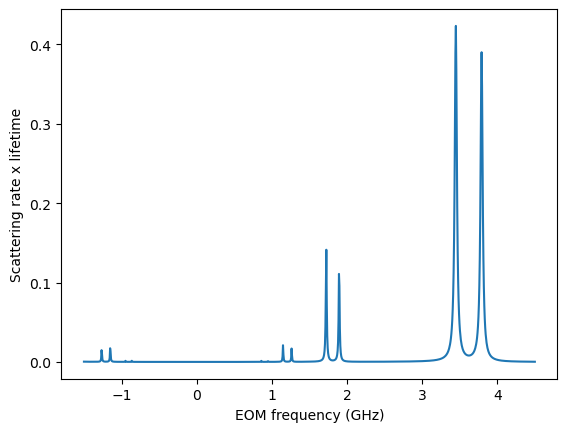

In [51]:
f, df = 1.5, 3
eom_freqs = jnp.linspace(f - df, f + df, 1000)
rates, branching_ratios = ph.scattering_rate(particle, control_state, eom_frequency=eom_freqs, max_bessel_order=4)
rates_summed = rates.sum(axis=(-3, -2, -1))
plt.plot(eom_freqs, rates_summed * particle.nondiff.excited_state_lifetime)
plt.xlabel("EOM frequency (GHz)")
plt.ylabel("Scattering rate x lifetime")
plt.show()

`testing.ipynb`'s next cell repeated this sweep over half of a 10,000-member
distribution (`idx = jnp.arange(N // 2, N)`) to exercise the batched,
multi-particle path of `scattering_rate`. That is exactly what
`jax.vmap`/`make_batched_helper` is for once you have more than one
`SnVParticle` — see the *Latin Hypercube Sampling* section at the end of this
notebook, which builds an `SnVDistribution` of many particles and vmaps a
`particle_helpers` function across all of them.

# Test Ground State Simulation

(6144,)
(6144,)


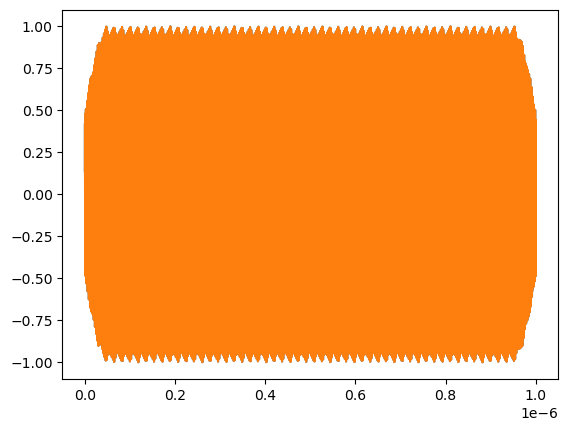

RMS error: 1.9198094567743907e-13


In [52]:
# -------------------------------------------------------------------------
# Example
# -------------------------------------------------------------------------
particle = particle_longitudinal
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

pulse = AnalogPulse(
    length=1e-6,
    apodization=Apodization.COSINE,
    apodization_length=1e-7,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=ph.get_emr_freqs(particle, control_state)[0] * 1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2e9,
    phase_offset=np.nan,
    name="",
)

# A zero-duration pulse cannot generate its own useful time grid, so supply
# the desired observation window explicitly.
tau = make_analog_pulse_time_array(pulse, 1 / 6.144e9, at_time=pulse.length / 2)

waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
true_waveform, true_envelope, true_tau = pulse.synthesize(tau, at_time=pulse.length / 2, dphase=0.0, all_info=True)
print(waveform.shape)
print(true_waveform.shape)
plt.plot(tau, waveform)
plt.plot(true_tau, true_waveform)
plt.show()
print("RMS error:", np.sqrt(np.mean((waveform - true_waveform) ** 2)))
assert np.all(np.isclose(waveform, true_waveform))
assert np.all(np.isclose(envelope, true_envelope))
assert np.all(np.isclose(tau, true_tau))

stacked_pulses = stack_waveforms([pulse, pulse])
# Use argument order, pass as positional arguments
stacked_waveforms, stacked_envelope, stacked_tau = jax.vmap(
    synthesize_analog_pulse,
    in_axes=(0, None, None, None, None)
)(
    stacked_pulses, tau, pulse.length / 2, True, 0.0
)

assert np.all(np.isclose(stacked_waveforms[0], true_waveform))
assert np.all(np.isclose(stacked_envelope[0], true_envelope))
assert np.all(np.isclose(stacked_tau[0], true_tau))
assert np.all(np.isclose(stacked_waveforms[1], true_waveform))
assert np.all(np.isclose(stacked_envelope[1], true_envelope))
assert np.all(np.isclose(stacked_tau[1], true_tau))

[1.9235214 1.9235214]
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[-0.9617607+8.24496944e-14j  0.       +0.00000000e+00j
   0.       +0.00000000e+00j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j -0.9617607-3.53830698e-14j
   0.       +0.00000000e+00j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j  0.       +0.00000000e+00j
   0.9617607-2.33838340e-14j  0.       +0.00000000e+00j]
 [ 0.       +0.00000000e+00j  0.       +0.00000000e+00j
   0.       +0.00000000e+00j  0.9617607-2.36827906e-14j]]
Quantum array: dims = ((4,), (4,)), bdims = (), shape = (4, 4), type = oper, impl = dense
Qarray data =
[[ 0.00000000e+00+0.j          0.00000000e+00+0.j
   3.06539332e-09+0.01901121j  0.00000000e+00+0.j        ]
 [ 0.00000000e+00+0.j          0.00000000e+00+0.j
   0.00000000e+00+0.j         -1.95451044e-12+0.01901121j]
 [ 3.06539331e-09-0.01901121j  0.00000000e+00+0.j
   0.00000000e+00+0.j          0.00000000e+00+0.j

100% |██████████| [00:02<00:00, 42.58%/s]


(614, 4, 1)


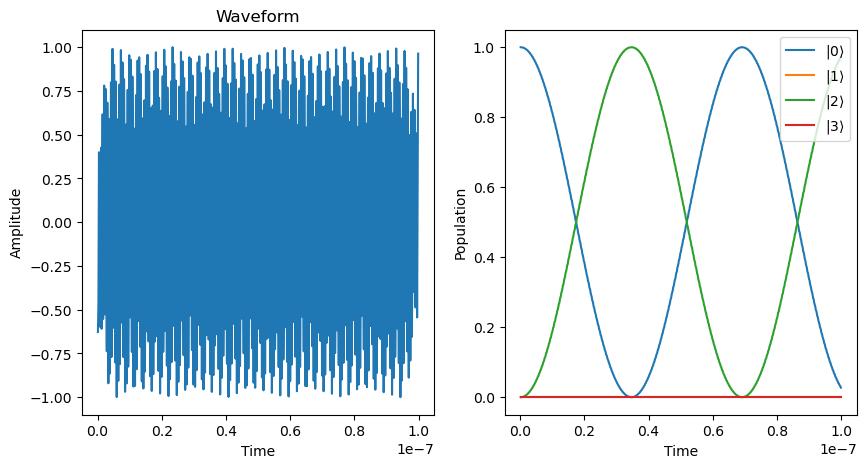

Quantum array: dims = ((4,), (1,)), bdims = (), shape = (4, 1), type = ket, impl = dense
Qarray data =
[[-0.16057807+0.04055905j]
 [ 0.        +0.j        ]
 [ 0.37393503-0.91254407j]
 [ 0.        +0.j        ]]


In [53]:
H0, Hb = ph.get_ground_hamiltonian(particle, control_state, included_states=(0,1,2,3))
diag = jnp.diag(H0.data).real
drive_freq_ghz = diag[3] - diag[0]   # the actually-coupled 0<->3 transition

pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=ph.get_emr_freqs(particle, control_state)[0] * 1e9,
    # frequency=drive_freq_ghz * 1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2e9,
    phase_offset=np.nan,
    name="",
)

sampling_rate_hz = 6.144e9

H0, Hb = ph.get_ground_hamiltonian(particle, control_state, included_states=(0, 1, 2, 3))
H0_rads_s = 2 * jnp.pi * H0 * 1e9
Hb_rads_s = 2 * jnp.pi * Hb * 1e9
print(ph.get_emr_freqs(particle, control_state))
print(H0)
print(Hb)


def H_t_func(t, args=None):
    return Hb_rads_s * synthesize_analog_pulse(pulse, jnp.asarray([t - 1 / sampling_rate_hz, t, t + 1 / sampling_rate_hz]), at_time=pulse.length / 2, dphase=0.0, all_info=True)[0][1] + H0_rads_s


psi0 = jqt.basis(4, 0)

tau = make_analog_pulse_time_array(pulse, 1 / sampling_rate_hz, at_time=pulse.length / 2)


waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)

save_times = tau[::]
states = jqt.sesolve(H_t_func, psi0, tau, saveat_tlist=save_times)
print(states.shape)

# Population operators |i><i|
projectors = [
    jqt.basis(4, i).to_dm()
    for i in range(4)
]

# <P_i> = Tr[P_i rho(t)]
populations = jnp.stack(
    [
        jnp.real(jqt.overlap(projector, states))
        for projector in projectors
    ],
    axis=0,
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(tau, waveform)
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")

for i in range(4):
    axs[1].plot(
        np.asarray(save_times),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

100% |██████████| [00:05<00:00, 17.07%/s]


(62, 1, 4, 1)
(62, 1)


/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


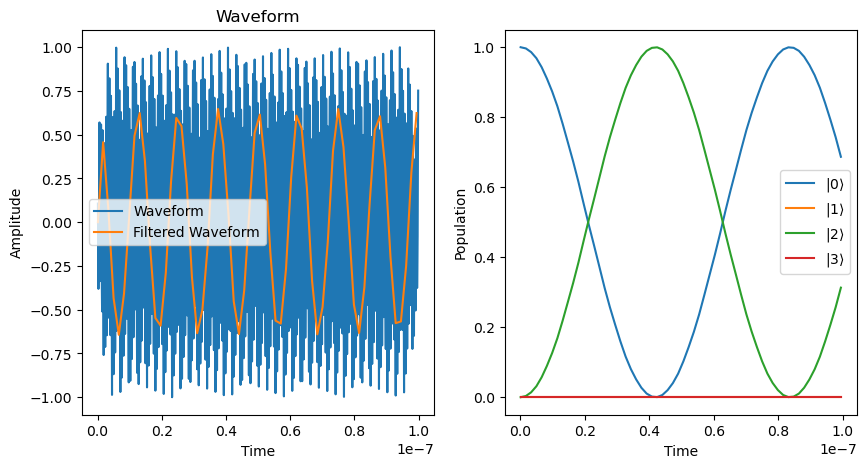

Quantum array: dims = ((4,), (1,)), bdims = (1,), shape = (1, 4, 1), type = ket, impl = dense
Qarray data =
[[[ 0.82629185-0.06470287j]
  [ 0.        +0.j        ]
  [-0.5467416 -0.11885465j]
  [ 0.        +0.j        ]]]


In [54]:
pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=ph.get_emr_freqs(particle, control_state)[0] * 1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)
H0, Hb = ph.get_ground_hamiltonian(particle, control_state, included_states=(0, 1, 2, 3))
H0_rads_s = 2 * jnp.pi * H0 * 1e9
Hb_rads_s = 2 * jnp.pi * Hb * 1e9
sampling_rate_hz = particle.nondiff.sampling_rate * 1e9


def H_b_drive(t, args=None):
    return synthesize_analog_pulse(pulse, jnp.asarray([t - 1 / sampling_rate_hz, t, t + 1 / sampling_rate_hz]), at_time=pulse.length / 2, dphase=0.0, all_info=True)[0][1]


def lowpass_filter(omega_c):
    """H(s) = omega_c / (s + omega_c)."""
    omega_c = jnp.asarray(omega_c)

    def filter_fn(t, z, u):
        del t
        dz_dt = omega_c * (u - z)
        output = z
        return dz_dt, output

    return filter_fn


hamiltonians = [H0_rads_s, Hb_rads_s]
coefficients = [1.0, H_b_drive]
omega_c = 2 * jnp.pi * particle.diffable.mw_B_bandwidth * 1e9
filters = [None, lowpass_filter(omega_c)]
filter_y0s = [None, jnp.zeros(1, dtype=jnp.complex128)]

psi0 = jqt.basis(4, 0)

tau = make_analog_pulse_time_array(pulse, 1 / sampling_rate_hz, at_time=pulse.length / 2)

save_times = tau[::10]
states, filter_states, = sesolve_components(hamiltonians, coefficients, psi0, tau, saveat_tlist=save_times, filters=filters, filter_y0s=filter_y0s, return_filter_states=True, solver_options=jqt.SolverOptions.create(progress_meter=True, solver="Dopri5"))
print(states.shape)
print(filter_states[1].shape)

# Population operators |i><i|
projectors = [
    jqt.basis(4, i).to_dm()
    for i in range(4)
]

# <P_i> = Tr[P_i rho(t)]
populations = jnp.stack(
    [
        jnp.real(jqt.overlap(projector, states))
        for projector in projectors
    ],
    axis=0,
)


waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(tau, waveform, label="Waveform")
axs[0].plot(save_times, filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(4):
    axs[1].plot(
        np.asarray(save_times),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


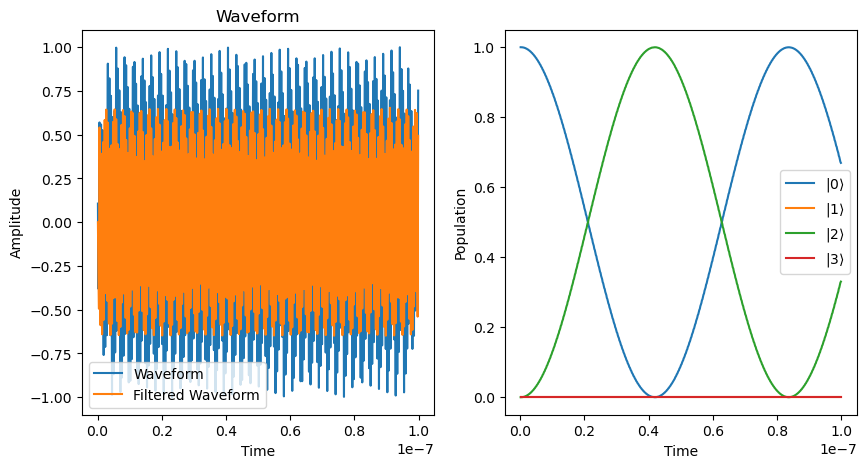

Quantum array: dims = ((4,), (1,)), bdims = (), shape = (4, 1), type = ket, impl = dense
Qarray data =
[[-0.78898922+0.21692593j]
 [ 0.        +0.j        ]
 [ 0.5278437 +0.22732838j]
 [ 0.        +0.j        ]]


In [55]:
pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=ph.get_emr_freqs(particle, control_state)[0] * 1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)

states, filter_states, populations = ph.drive_mw_hamiltonian(
    particle,
    control_state,
    pulse,
    included_states=(0, 1, 2, 3),
    saveat_final_only=False,
)

tau = make_analog_pulse_time_array(pulse, 1 / particle.nondiff.sampling_rate / 1e9, at_time=pulse.length / 2)
waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(returned_tau, waveform, label="Waveform")
axs[0].plot(returned_tau, filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(4):
    axs[1].plot(
        np.asarray(returned_tau),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

## Verify low pass filtering accuracy

`testing.ipynb`'s equivalent cell quietly depended on `filter_states` and
`save_times` left over from an earlier, differently-sampled cell (its own
`save_times = tau[::]` line is dead code — the comparison below actually used
`tau[::10]` from a previous cell). That is fragile to run out of order, so
this version recomputes everything it needs in one place: it drives the same
single-pole low-pass filter through `sesolve_components` and then integrates
the identical filter ODE standalone with `diffrax`, and compares the two.

/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


Cutoff frequency:      1.500000e+09 Hz
Filter time constant:  1.061033e-10 s
Raw-drive peak:        1.000000e+00
Filtered-drive peak:   6.470175e-01
Maximum abs error:     1.025145e-04
Relative RMS error:    4.151263e-05


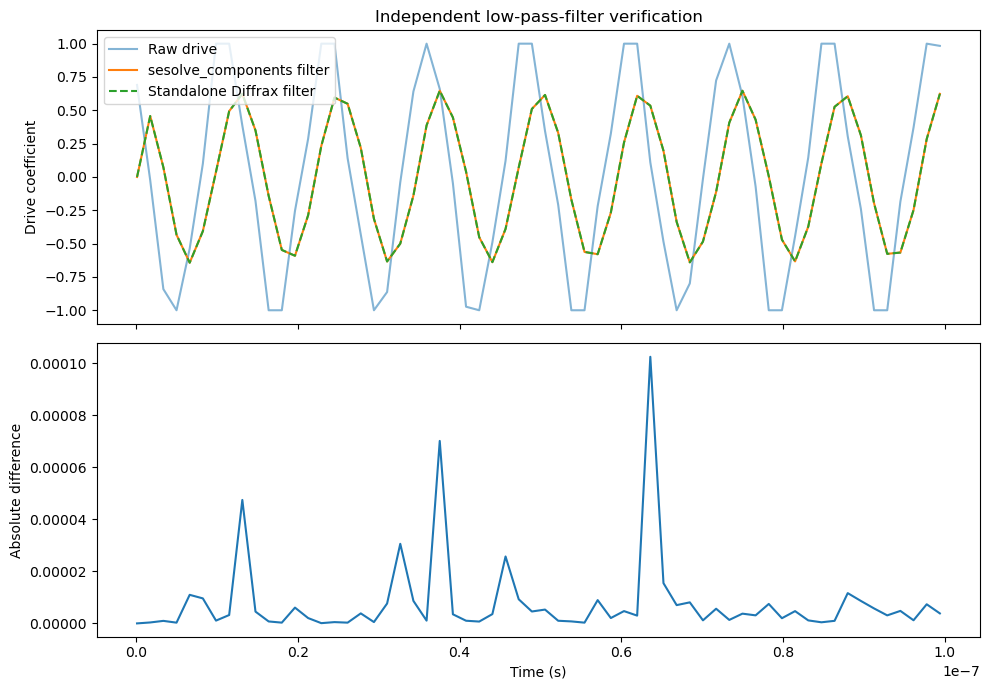

In [56]:
import diffrax as dfx
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

particle = particle_longitudinal
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=ph.get_emr_freqs(particle, control_state)[0] * 1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)

H0, Hb = ph.get_ground_hamiltonian(particle, control_state, included_states=(0, 1, 2, 3))
H0_rads_s = 2 * jnp.pi * H0 * 1e9
Hb_rads_s = 2 * jnp.pi * Hb * 1e9
sampling_rate_hz = particle.nondiff.sampling_rate * 1e9


def H_b_drive(t, args=None):
    return synthesize_analog_pulse(pulse, jnp.asarray([t - 1 / sampling_rate_hz, t, t + 1 / sampling_rate_hz]), at_time=pulse.length / 2, dphase=0.0, all_info=True)[0][1]


def lowpass_filter(omega_c):
    """H(s) = omega_c / (s + omega_c)."""
    omega_c = jnp.asarray(omega_c)

    def filter_fn(t, z, u):
        del t
        dz_dt = omega_c * (u - z)
        output = z
        return dz_dt, output

    return filter_fn


hamiltonians = [H0_rads_s, Hb_rads_s]
coefficients = [1.0, H_b_drive]
omega_c = 2 * jnp.pi * particle.diffable.mw_B_bandwidth * 1e9
filters = [None, lowpass_filter(omega_c)]
filter_y0s = [None, jnp.zeros(1, dtype=jnp.complex128)]

psi0 = jqt.basis(4, 0)

tau = make_analog_pulse_time_array(pulse, 1 / sampling_rate_hz, at_time=pulse.length / 2)
save_times = tau[::10]

states, filter_states = sesolve_components(
    hamiltonians, coefficients, psi0, tau,
    saveat_tlist=save_times, filters=filters, filter_y0s=filter_y0s,
    return_filter_states=True,
    solver_options=jqt.SolverOptions.create(progress_meter=False, solver="Dopri5"),
)

# ---------------------------------------------------------------------------
# Standalone Diffrax verification of the low-pass-filter state
# ---------------------------------------------------------------------------

save_times_check = jnp.asarray(save_times)

# Use exactly the same initial state as the coupled quantum/filter solve.
filter_y0_check = jnp.asarray(filter_y0s[1])


def standalone_lowpass_rhs(t, z, args):
    """Single-pole low-pass filter with no quantum-system evolution."""
    del args

    # This is the exact same raw coefficient entering sesolve_components.
    raw_drive = jnp.asarray(H_b_drive(t), dtype=z.dtype)
    cutoff = jnp.asarray(omega_c, dtype=z.dtype)

    return cutoff * (raw_drive - z)


standalone_solution = dfx.diffeqsolve(
    terms=dfx.ODETerm(standalone_lowpass_rhs),
    solver=dfx.Tsit5(),
    t0=save_times_check[0],
    t1=save_times_check[-1],

    # Match JAXQuantum's initial-step choice.
    dt0=save_times_check[1] - save_times_check[0],

    y0=filter_y0_check,

    # Save only at the comparison times; no dense solution is constructed.
    saveat=dfx.SaveAt(ts=save_times_check),

    stepsize_controller=dfx.PIDController(
        rtol=1e-7,
        atol=1e-9,
    ),
    max_steps=100_000,
    progress_meter=dfx.NoProgressMeter(),
)

# Ensure execution is complete before timing, printing, or plotting.
standalone_filtered = jax.block_until_ready(standalone_solution.ys)

# filter_states is aligned with the Hamiltonian list:
# filter_states[0] is None and filter_states[1] is the filtered Hb coefficient.
coupled_filtered = jax.block_until_ready(
    jnp.asarray(filter_states[1])
)

# Remove a trailing singleton state dimension, if present.
standalone_filtered_1d = jnp.squeeze(standalone_filtered)
coupled_filtered_1d = jnp.squeeze(coupled_filtered)

if standalone_filtered_1d.shape != coupled_filtered_1d.shape:
    raise ValueError(
        "Filter-output shapes do not match:\n"
        f"  standalone Diffrax: {standalone_filtered_1d.shape}\n"
        f"  sesolve_components: {coupled_filtered_1d.shape}"
    )

# Sample the unfiltered drive only for plotting.
raw_drive_values = jax.vmap(H_b_drive)(save_times_check)
raw_drive_values = jax.block_until_ready(raw_drive_values)

# ---------------------------------------------------------------------------
# Numerical comparison
# ---------------------------------------------------------------------------

error = coupled_filtered_1d - standalone_filtered_1d

max_abs_error = jnp.max(jnp.abs(error))
rms_error = jnp.sqrt(jnp.mean(jnp.abs(error) ** 2))
reference_rms = jnp.sqrt(
    jnp.mean(jnp.abs(standalone_filtered_1d) ** 2)
)
relative_rms_error = rms_error / jnp.maximum(
    reference_rms,
    jnp.finfo(reference_rms.dtype).eps,
)

print(
    "Cutoff frequency:      "
    f"{float(omega_c / (2.0 * jnp.pi)):.6e} Hz"
)
print(
    "Filter time constant:  "
    f"{float(1.0 / omega_c):.6e} s"
)
print(
    "Raw-drive peak:        "
    f"{float(jnp.max(jnp.abs(raw_drive_values))):.6e}"
)
print(
    "Filtered-drive peak:   "
    f"{float(jnp.max(jnp.abs(coupled_filtered_1d))):.6e}"
)
print(
    "Maximum abs error:     "
    f"{float(max_abs_error):.6e}"
)
print(
    "Relative RMS error:    "
    f"{float(relative_rms_error):.6e}"
)

# ---------------------------------------------------------------------------
# Plot the independently evolved filter and comparison error
# ---------------------------------------------------------------------------

times_np = np.asarray(save_times_check)
raw_np = np.real_if_close(np.asarray(raw_drive_values))
coupled_np = np.real_if_close(np.asarray(coupled_filtered_1d))
standalone_np = np.real_if_close(np.asarray(standalone_filtered_1d))
error_np = np.asarray(jnp.abs(error))

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 7),
    sharex=True,
)

axes[0].plot(
    times_np,
    raw_np,
    label="Raw drive",
    alpha=0.55,
)
axes[0].plot(
    times_np,
    coupled_np,
    label="sesolve_components filter",
)
axes[0].plot(
    times_np,
    standalone_np,
    "--",
    label="Standalone Diffrax filter",
)

axes[0].set_title("Independent low-pass-filter verification")
axes[0].set_ylabel("Drive coefficient")
axes[0].legend()

axes[1].plot(
    times_np,
    error_np,
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Absolute difference")

plt.tight_layout()
plt.show()

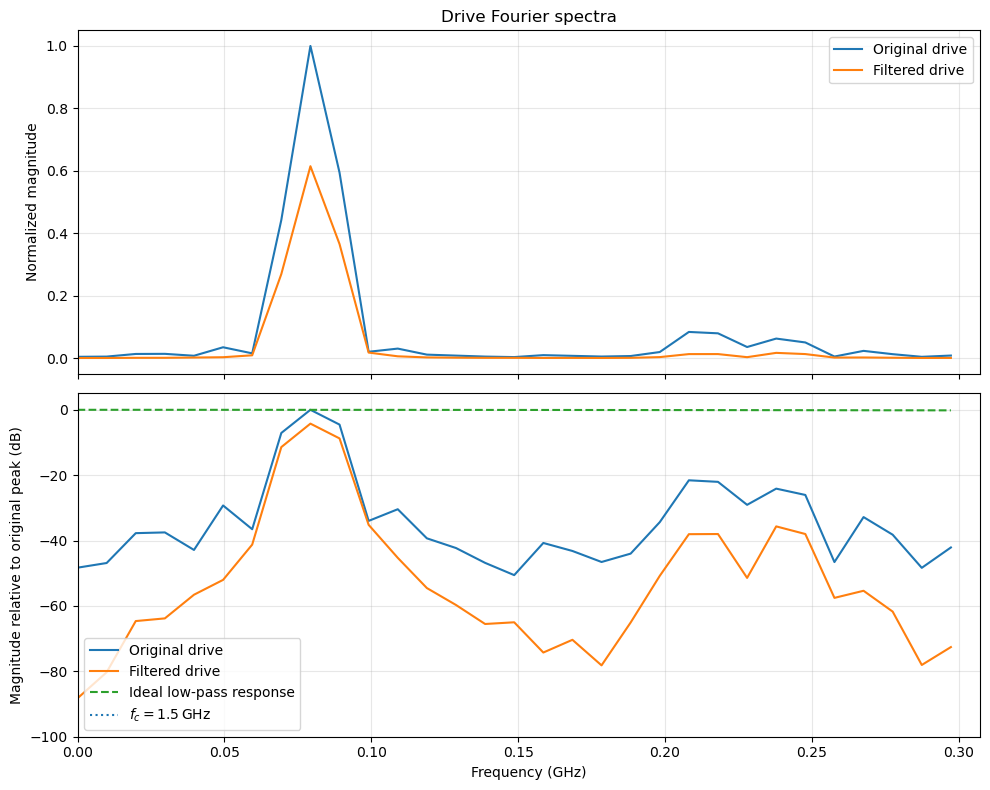

Sample rate:       0.614400 GHz
Nyquist frequency: 0.307200 GHz
Filter cutoff:     1.500000 GHz


In [57]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------------
# Fourier spectra of the original and low-pass-filtered drive
# ---------------------------------------------------------------------------

times = np.asarray(save_times, dtype=np.float64)

# Evaluate the original drive at the same uniformly spaced times used for
# saving the filtered state.
original_signal = np.asarray(
    jax.vmap(H_b_drive)(jnp.asarray(save_times))
).squeeze()

# For the low-pass filter used here, the filter state is also its output.
filtered_signal = np.asarray(filter_states[1]).squeeze()

if original_signal.shape != filtered_signal.shape:
    raise ValueError(
        "Original and filtered signals have different shapes:\n"
        f"  original: {original_signal.shape}\n"
        f"  filtered: {filtered_signal.shape}"
    )

if times.ndim != 1 or times.size != original_signal.size:
    raise ValueError(
        "save_times must be one-dimensional and have one entry per signal sample."
    )

# An FFT requires uniformly spaced sample times.
time_steps = np.diff(times)
dt = np.mean(time_steps)

if not np.allclose(time_steps, dt, rtol=1e-6, atol=1e-15):
    raise ValueError(
        "save_times are not uniformly spaced, so a standard FFT is not valid."
    )

sample_rate = 1.0 / dt
nyquist_frequency = 0.5 * sample_rate

# A Hann window reduces spectral leakage caused by truncating the finite pulse.
window = np.hanning(original_signal.size)

# Correct approximately for the coherent amplitude loss caused by the window.
coherent_gain = np.mean(window)

original_fft = np.fft.fft(original_signal * window)
filtered_fft = np.fft.fft(filtered_signal * window)

frequencies = np.fft.fftfreq(original_signal.size, d=dt)

# Keep the nonnegative-frequency half of the spectrum.
positive = frequencies >= 0.0
frequencies_positive = frequencies[positive]

original_magnitude = np.abs(original_fft[positive])
filtered_magnitude = np.abs(filtered_fft[positive])

# Normalize both spectra to the same reference: the original-signal peak.
reference = max(
    np.max(original_magnitude),
    np.finfo(np.float64).tiny,
)

original_normalized = original_magnitude / reference
filtered_normalized = filtered_magnitude / reference

# Convert to decibels while avoiding log10(0).
minimum_linear_amplitude = 1e-12
original_db = 20.0 * np.log10(
    np.maximum(original_normalized, minimum_linear_amplitude)
)
filtered_db = 20.0 * np.log10(
    np.maximum(filtered_normalized, minimum_linear_amplitude)
)

# Optional theoretical magnitude response of the single-pole low-pass filter:
#
#     |H(f)| = 1 / sqrt(1 + (f / f_c)^2)
#
# This uses the same omega_c supplied to lowpass_filter.
cutoff_hz = float(omega_c / (2.0 * jnp.pi))

theoretical_lowpass = 1.0 / np.sqrt(
    1.0 + (frequencies_positive / cutoff_hz) ** 2
)
theoretical_lowpass_db = 20.0 * np.log10(
    np.maximum(theoretical_lowpass, minimum_linear_amplitude)
)

# ---------------------------------------------------------------------------
# Plot
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(10, 8),
    sharex=True,
)

frequency_ghz = frequencies_positive / 1e9

axes[0].plot(
    frequency_ghz,
    original_normalized,
    label="Original drive",
)
axes[0].plot(
    frequency_ghz,
    filtered_normalized,
    label="Filtered drive",
)
axes[0].set_ylabel("Normalized magnitude")
axes[0].set_title("Drive Fourier spectra")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(
    frequency_ghz,
    original_db,
    label="Original drive",
)
axes[1].plot(
    frequency_ghz,
    filtered_db,
    label="Filtered drive",
)
axes[1].plot(
    frequency_ghz,
    theoretical_lowpass_db,
    "--",
    label="Ideal low-pass response",
)
axes[1].axvline(
    cutoff_hz / 1e9,
    linestyle=":",
    label=fr"$f_c={cutoff_hz / 1e9:.3g}\,\mathrm{{GHz}}$",
)

axes[1].set_xlabel("Frequency (GHz)")
axes[1].set_ylabel("Magnitude relative to original peak (dB)")
axes[1].set_ylim(-100.0, 5.0)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Display only the physically represented positive-frequency range.
axes[1].set_xlim(0.0, nyquist_frequency / 1e9)

plt.tight_layout()
plt.show()

print(f"Sample rate:       {sample_rate / 1e9:.6f} GHz")
print(f"Nyquist frequency: {nyquist_frequency / 1e9:.6f} GHz")
print(f"Filter cutoff:     {cutoff_hz / 1e9:.6f} GHz")

## Benchmark Accuracy vs Tolerance

`testing.ipynb` also compared a `scale=1` "unscaled" pulse against the
default GHz/ns scaling, exercising a `scale` keyword that
`particle_helpers.drive_mw_hamiltonian` does not expose (it always works in
the same fixed GHz/ns/tesla units as `distribution.py`). That branch is
dropped below; the solver-tolerance sweep itself is unaffected.

atol: 1e-09, rtol: 1.0000000000000001e-07


100% |██████████| [00:10<00:00,  9.64%/s]


atol: 9.999999999999999e-09, rtol: 9.999999999999978e-07


100% |██████████| [00:06<00:00, 15.97%/s]


atol: 1.0000000000000001e-07, rtol: 9.999999999999999e-06


...

100% |██████████| [00:01<00:00, 69.52%/s]


atol: 9.999999999999999e-06, rtol: 0.001


100% |██████████| [00:00<00:00, 122.86%/s]


atol: 9.999999999999999e-05, rtol: 0.01


100% |██████████| [00:00<00:00, 221.80%/s]


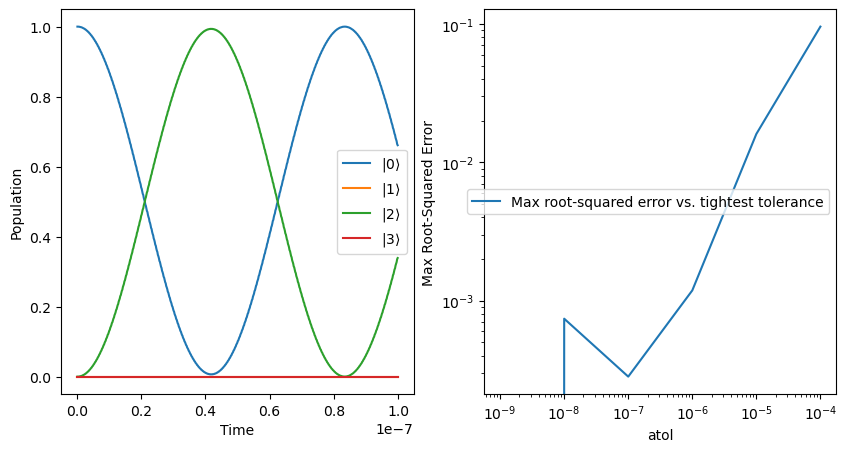

In [58]:
particle = particle_longitudinal
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=ph.get_emr_freqs(particle, control_state)[0] * 1e9 + 1e6,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)

sweep_length = 6
atols = jnp.logspace(-9, -4, sweep_length)
rtols = jnp.logspace(-7, -2, sweep_length)
populations_sweep = []
max_rs_error_sweep = []
for i, (atol, rtol) in enumerate(zip(atols, rtols)):
    print(f"atol: {atol}, rtol: {rtol}")
    solver_options_args = (True, "Dopri5", int(1e5), float(rtol), float(atol))
    states, filter_states, populations = ph.drive_mw_hamiltonian(
        particle,
        control_state,
        pulse,
        included_states=(0, 1, 2, 3),
        saveat_final_only=False,
        solver_options_args=solver_options_args,
    )
    populations_sweep.append(populations)
    max_rs_error_sweep.append(jnp.sqrt(jnp.max(jnp.square(populations[:, -1] - populations_sweep[0][:, -1]))))


tau = make_analog_pulse_time_array(pulse, 1 / particle.nondiff.sampling_rate / 1e9, at_time=pulse.length / 2)
waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

for i in range(4):
    axs[0].plot(
        np.asarray(returned_tau),
        np.asarray(populations_sweep[0][i]),
        label=fr"$|{i}\rangle$",
    )

axs[0].set_xlabel("Time")
axs[0].set_ylabel("Population")
axs[0].legend()

axs[1].plot(atols, max_rs_error_sweep, label="Max root-squared error vs. tightest tolerance")
axs[1].set_xlabel("atol")
axs[1].set_ylabel("Max Root-Squared Error")
axs[1].set_xscale("log")
axs[1].set_yscale("log")
axs[1].legend()
plt.show()

## Benchmark Time

`testing.ipynb` swept the *distribution size* `N` and called
`dist.drive_mw_hamiltonian(idx=None, ...)`, which internally `vmap`s the
per-member solve across all `N` distribution indices. `particle_helpers`
functions operate on one `SnVParticle` at a time, so the direct analogue of
that sweep is: build an `SnVDistribution` of `N` copies of the same particle
with `SnVDistribution.from_particles`, then `jax.vmap` a `particle_helpers`
solve across the batch axis (one control state shared by every particle —
exactly like `control_state` held constant across `idx` in the old batched
call).

One caveat found while writing this benchmark: `particle_helpers.drive_mw_hamiltonian`
is not directly `vmap`-able through `particle.make_batched_helper`. Its public
wrapper builds the pulse's time grid with `float(particle.nondiff.sampling_rate)`
*outside* JIT (the grid length has to be a static Python int), and `vmap`
turns `particle.nondiff.sampling_rate` into a traced array, so that `float()`
call raises `TracerArrayConversionError`. Since every particle in this
benchmark shares the same `sampling_rate`, the fix is to build the time grid
once (exactly as `distribution.py`'s own batched core does) and `vmap` the
jitted `_drive_mw_hamiltonian` solve directly.


Benchmarking N = 10
  Mean:   1378.307 ms
  Median: 1378.484 ms
  Min:    1377.556 ms
  Max:    1379.049 ms

Benchmarking N = 23
  Mean:   1554.330 ms
  Median: 1554.003 ms
  Min:    1553.314 ms
  Max:    1556.202 ms

Benchmarking N = 56
  Mean:   1599.727 ms
  Median: 1601.096 ms
  Min:    1595.697 ms
  Max:    1604.317 ms

Benchmarking N = 133
  Mean:   1634.753 ms
  Median: 1634.699 ms
  Min:    1632.937 ms
  Max:    1636.832 ms

Benchmarking N = 316
  Mean:   1801.924 ms
  Median: 1801.018 ms
  Min:    1796.133 ms
  Max:    1807.515 ms

Benchmarking N = 749
  Mean:   1818.548 ms
  Median: 1817.448 ms
  Min:    1815.679 ms
  Max:    1823.768 ms

Benchmarking N = 1,778
  Mean:   1645.539 ms
  Median: 1645.795 ms
  Min:    1643.171 ms
  Max:    1647.048 ms

Benchmarking N = 4,216
  Mean:   1905.737 ms
  Median: 1905.863 ms
  Min:    1905.051 ms
  Max:    1906.276 ms

Benchmarking N = 10,000
  Mean:   2342.099 ms
  Median: 2342.303 ms
  Min:    2340.037 ms
  Max:    2343.791 ms

Stead

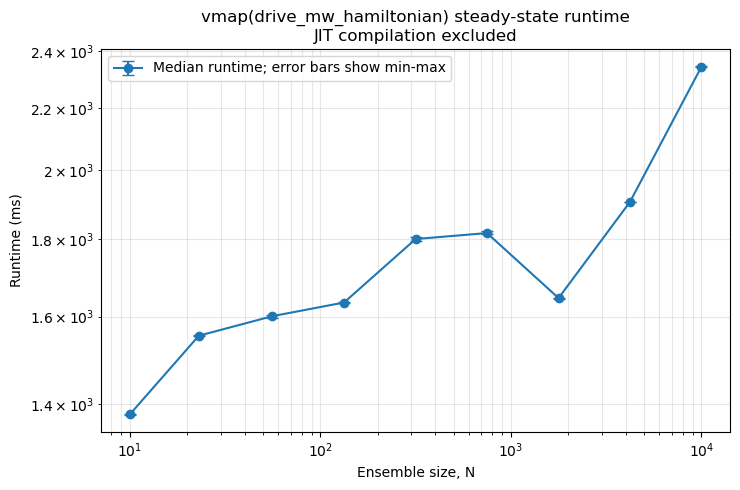

In [59]:
import gc
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from functools import partial


def block_until_ready_tree(tree):
    """Block until all JAX array leaves have finished executing."""
    return jax.tree_util.tree_map(
        lambda leaf: (
            leaf.block_until_ready()
            if hasattr(leaf, "block_until_ready")
            else leaf
        ),
        tree,
    )


# -------------------------------------------------------------------------
# Benchmark configuration
# -------------------------------------------------------------------------

N_values = np.asarray(jnp.logspace(1, 4, 9), dtype=np.int64)
N_values = np.unique(N_values)

num_warmup_runs = 1
num_timed_runs = 5

solver_options_args = (
    False,
    "Dopri5",
    int(1e5),
    float(1e-4),
    float(1e-6),
)

included_states = (0, 1, 2, 3)

all_run_times = np.empty(
    (len(N_values), num_timed_runs),
    dtype=float,
)

particle = particle_longitudinal
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

pulse = AnalogPulse(
    length=100e-9,
    apodization=Apodization.COSINE,
    apodization_length=10e-9,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=ph.get_emr_freqs(particle, control_state)[0] * 1e9,
    frequency_chirp=0,
    shape=Shape.TRIANGLE,
    S21_correct=True,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)


# The pulse's time grid depends only on `sampling_rate`, which every particle
# in this benchmark shares, so it is built once outside JIT/vmap — exactly
# like `distribution.py`'s own `_drive_mw_hamiltonian_batch` does for its
# `idx` batch. `particle_helpers._drive_mw_hamiltonian` is the jitted,
# tau-already-built core that `drive_mw_hamiltonian` normally calls for you;
# vmapping it directly sidesteps the host-side `float()` conversion in the
# public wrapper (see the note above).
scale = 1e9
sample_period = 1.0 / (float(np.asarray(particle.nondiff.sampling_rate)) * scale)
tau = make_analog_pulse_time_array(
    pulse, sample_period, at_time=float(np.asarray(pulse.length)) / 2.0
)
psi0 = jqt.basis(len(included_states), 0)

batched_drive_mw_hamiltonian = jax.vmap(
    ph._drive_mw_hamiltonian,
    in_axes=(0, None, None, None, None, None, None, None),
)


# -------------------------------------------------------------------------
# Benchmark a vmapped drive_mw_hamiltonian for each ensemble size
# -------------------------------------------------------------------------

for N_index, N in enumerate(N_values):
    N = int(N)

    print(f"\nBenchmarking N = {N:,}")

    # Ensemble construction is intentionally outside the timed region.
    ensemble = SnVDistribution.from_particles([particle] * N)

    # ---------------------------------------------------------------------
    # Warm-up: compile the N-dependent array shapes.
    # ---------------------------------------------------------------------

    for _ in range(num_warmup_runs):
        warmup_result = batched_drive_mw_hamiltonian(
            ensemble.particles, control_state, pulse, tau, psi0,
            included_states, True, solver_options_args,
        )
        block_until_ready_tree(warmup_result)

    del warmup_result
    gc.collect()

    # ---------------------------------------------------------------------
    # Timed steady-state executions
    # ---------------------------------------------------------------------

    for run_index in range(num_timed_runs):
        start_time = time.perf_counter()

        benchmark_result = batched_drive_mw_hamiltonian(
            ensemble.particles, control_state, pulse, tau, psi0,
            included_states, True, solver_options_args,
        )

        # JAX dispatch is asynchronous. Blocking here ensures the timer
        # measures execution, not merely operation dispatch.
        block_until_ready_tree(benchmark_result)

        all_run_times[N_index, run_index] = (
            time.perf_counter() - start_time
        )

    run_times_ms = all_run_times[N_index] * 1e3

    print(f"  Mean:   {run_times_ms.mean():.3f} ms")
    print(f"  Median: {np.median(run_times_ms):.3f} ms")
    print(f"  Min:    {run_times_ms.min():.3f} ms")
    print(f"  Max:    {run_times_ms.max():.3f} ms")

    del benchmark_result
    del ensemble
    gc.collect()


# -------------------------------------------------------------------------
# Calculate summary statistics
# -------------------------------------------------------------------------

run_times_ms = all_run_times * 1e3

mean_times_ms = np.mean(run_times_ms, axis=1)
median_times_ms = np.median(run_times_ms, axis=1)
min_times_ms = np.min(run_times_ms, axis=1)
max_times_ms = np.max(run_times_ms, axis=1)

lower_error_ms = median_times_ms - min_times_ms
upper_error_ms = max_times_ms - median_times_ms


# -------------------------------------------------------------------------
# Print summary table
# -------------------------------------------------------------------------

print("\nSteady-state vmapped drive_mw_hamiltonian benchmark")
print("Compilation excluded")
print("-" * 82)
print(
    f"{'N':>10}"
    f"{'Mean (ms)':>15}"
    f"{'Median (ms)':>15}"
    f"{'Min (ms)':>15}"
    f"{'Max (ms)':>15}"
)
print("-" * 82)

for N, mean, median, minimum, maximum in zip(
    N_values,
    mean_times_ms,
    median_times_ms,
    min_times_ms,
    max_times_ms,
):
    print(
        f"{int(N):>10,}"
        f"{mean:>15.3f}"
        f"{median:>15.3f}"
        f"{minimum:>15.3f}"
        f"{maximum:>15.3f}"
    )


# -------------------------------------------------------------------------
# Plot median steady-state runtime
# -------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(7.5, 5.0))

ax.errorbar(
    N_values,
    median_times_ms,
    yerr=np.vstack((lower_error_ms, upper_error_ms)),
    marker="o",
    capsize=4,
    linewidth=1.5,
    label="Median runtime; error bars show min-max",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Ensemble size, N")
ax.set_ylabel("Runtime (ms)")
ax.set_title(
    "vmap(drive_mw_hamiltonian) steady-state runtime\n"
    "JIT compilation excluded"
)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()

plt.show()

# Test Excited State Simulation

`testing.ipynb` passed `experiment_idx=None`/`experiment_idx=0` to
`get_excitation_hamiltonian`, `drive_excitation_hamiltonian`, and
`scattering_rate`. Neither `distribution.py` nor `particle_helpers.py`
exposes an `experiment_idx` parameter on these methods, so it is dropped
below; everything else carries over directly.

In [60]:
particle = particle_longitudinal
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)

H0, Hb, Hs_optical, c_ops, optical_transition_offset = ph.get_excitation_hamiltonian(
    particle,
    control_state,
    included_states=(0, 1, 2, 3),
)
print(H0)
print(H0.data.shape)
print(jnp.mean(H0.data[:8, :8]))
print(jnp.mean(H0.data[8:, 8:]))
print(optical_transition_offset)
print(params.LEVEL_OFFSET - particle.nondiff.laser_frequency + particle.diffable.strain_params[0] + optical_transition_offset)

Quantum array: dims = ((9,), (9,)), bdims = (), shape = (9, 9), type = oper, impl = dense
Qarray data =
[[-0.9617607 +8.24496944e-14j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j -0.9617607 -3.53830698e-14j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.9617607 -2.33838340e-14j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j]
 [ 0.        +0.00000000e+00j  0.        +0.00000000e+00j
   0.        +0.00000000e+00j  0.9617607 -2.36827

100% |██████████| [09:41<00:00,  5.82s/%]
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


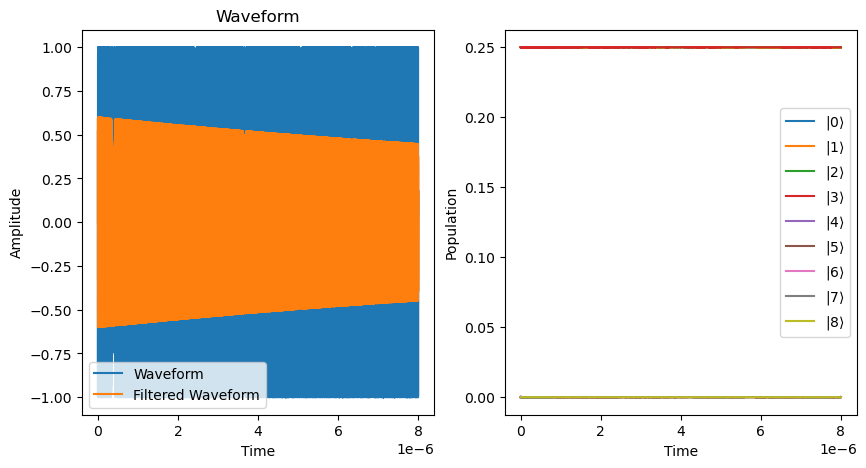

Quantum array: dims = ((9,), (9,)), bdims = (), shape = (9, 9), type = oper, impl = dense
Qarray data =
[[ 2.49859234e-01+3.79231564e-13j  0.00000000e+00+0.00000000e+00j
  -7.50430788e-07-1.13515354e-06j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -5.64833867e-04+5.68379760e-03j
  -1.65386907e-05+5.68242380e-06j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  2.49859234e-01-2.10511449e-13j
   0.00000000e+00+0.00000000e+00j -7.50430601e-07-1.13515366e-06j
  -5.64834795e-04+5.68379751e-03j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j -1.65386916e-05+5.68242113e-06j
   0.00000000e+00+0.00000000e+00j]
 [-7.50430781e-07+1.13515354e-06j  0.00000000e+00+0.00000000e+00j
   2.49959039e-01-1.40585016e-13j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j  2.08313233e-05-3.26004058e-06j
  -6.68599211e-04+3.49811747e-03j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]

In [63]:
downsampling = 1
pulse = AnalogPulse(
    length=8e-6,
    apodization=Apodization.COSINE,
    apodization_length=0,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=2.5e9,
    frequency_chirp=1e9,
    shape=Shape.SINUSOID,
    S21_correct=False,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)
wf = CompositeWaveform([pulse])
rho0 = 0.25 * jqt.ket2dm(jqt.basis(9, 0)) + 0.25 * jqt.ket2dm(jqt.basis(9, 1)) \
     + 0.25 * jqt.ket2dm(jqt.basis(9, 2)) + 0.25 * jqt.ket2dm(jqt.basis(9, 3))
states, filter_states, populations = ph.drive_excitation_hamiltonian(
    particle,
    control_state,
    wf,
    included_states=(0, 1, 2, 3),
    saveat_downsampling=downsampling,
    solver_options_args=(True, "Tsit5", int(1e9), 1e-5, 1e-7),
    rho0=rho0,
)

tau = make_analog_pulse_time_array(pulse, 1 / particle.nondiff.sampling_rate / 1e9, at_time=pulse.length / 2)
waveform, envelope, returned_tau = synthesize_analog_pulse(
    pulse=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(returned_tau, waveform, label="Waveform")
axs[0].plot(returned_tau[::downsampling], filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(9):
    axs[1].plot(
        np.asarray(returned_tau[::downsampling]),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

In [1]:
f, df = 2.5, 2
eom_freqs = jnp.linspace(f - df / 2, f + df / 2, 100000)
rates, branching_ratios = ph.scattering_rate(particle, control_state, eom_frequency=eom_freqs, max_bessel_order=4)
# One particle: sum the sideband/transition axes rather than the old
# `sum_counts=True` distribution-summing keyword.
rates_summed = rates.sum(axis=(-3, -2, -1))/4
scattering_rate_result = np.asarray(rates_summed * particle.nondiff.excited_state_lifetime)
mesolve_result = np.sum(np.asarray(populations[4:]), axis=0)

factor = df * 1e9 / 8e-6
mesolve_freqs = np.asarray(returned_tau[::downsampling] * factor + (f - df / 2) * 1e9)
eom_freqs_np = np.asarray(eom_freqs)
mesolve_result_interpolated = np.interp(
    eom_freqs_np,
    mesolve_freqs / 1e9,
    mesolve_result,
 )

root_squared_error = np.abs(scattering_rate_result/4 - mesolve_result_interpolated)
rmse = np.sqrt(np.mean(root_squared_error ** 2))
print(f"RMSE: {rmse:.6e}")

fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True)
axs[0].plot(
    eom_freqs_np,
    mesolve_result_interpolated,
    label="MESolve result (interpolated)",
 )
axs[0].plot(eom_freqs_np, scattering_rate_result/4, label="Scattering rate result")
axs[0].set_ylabel("Excited state population")
axs[0].legend()

axs[1].plot(eom_freqs_np, root_squared_error, label="Root squared error")

pad = (np.max(scattering_rate_result) - np.min(mesolve_result)) * 0.05
axs[0].set_ylim(np.min(mesolve_result) - pad, np.max(scattering_rate_result) + pad)
axs[1].set_ylim(np.min(mesolve_result) - pad, np.max(scattering_rate_result) + pad)
axs[1].set_xlabel("Frequency (Hz)")
axs[1].set_ylabel("Absolute error")
axs[1].legend()

plt.tight_layout()
plt.show()

NameError: name 'jnp' is not defined

# Cyclicity

[[0.98952323 0.         0.01047677 0.         0.         0.
  0.         0.        ]
 [0.         0.98952323 0.         0.01047677 0.         0.
  0.         0.        ]
 [0.01046046 0.         0.98953954 0.         0.         0.
  0.         0.        ]
 [0.         0.01046046 0.         0.98953954 0.         0.
  0.         0.        ]
 [0.98560814 0.         0.01439186 0.         0.         0.
  0.         0.        ]
 [0.         0.98560814 0.         0.01439186 0.         0.
  0.         0.        ]
 [0.01434245 0.         0.98565755 0.         0.         0.
  0.         0.        ]
 [0.         0.01434245 0.         0.98565755 0.         0.
  0.         0.        ]]
PLE Freqs: [484309.28331572 484309.28331572 484309.65336805 484309.65336805]
2.0


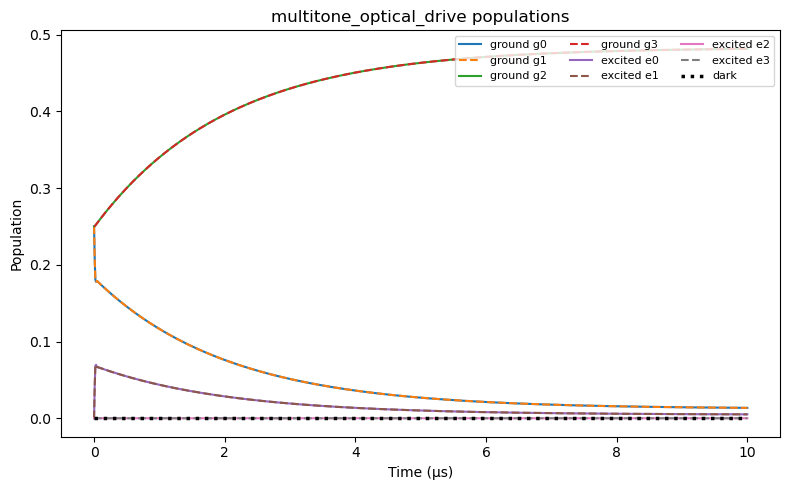

In [ ]:
particle = particle_longitudinal_high_strain
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)
scattering_rates, branching_ratios = ph.scattering_rate(particle, control_state, eom_frequency=0.0)
print(branching_ratios)
ple_freqs = ph.get_ple_freqs(particle, control_state)
print(f"PLE Freqs: {ple_freqs}")
updated_laser = particle.nondiff._replace(laser_frequency=ple_freqs[0]-2)
particle = particle._replace(nondiff=updated_laser)

eom_freqs = ple_freqs[0] - particle.nondiff.laser_frequency
print(eom_freqs)
eom_amps = jnp.asarray([1])

tlist = jnp.linspace(0, 10e-6, 1000)
dimension = 2 * 4 + 1  # default included_states=(0, 1, 2, 3)
rho0 = sum(jqt.ket2dm(jqt.basis(dimension, i)) for i in range(4)) / 4.0
rhos, pops = ph.multitone_optical_drive(particle, control_state, rho0, eom_freqs, eom_amps, tlist, max_detuning=2/6)
t_us = np.asarray(tlist) * 1e6
pops_np = np.asarray(pops)

fig, ax = plt.subplots(figsize=(8, 5))

# ground_colors = plt.cm.Blues(np.linspace(0.4, 0.9, 4))
# excited_colors = plt.cm.Reds(np.linspace(0.4, 0.9, 4))
styles = ['-','--','-', '--']

for i in range(4):
    ax.plot(t_us, pops_np[i], label=f"ground g{i}", linestyle=styles[i])
for i in range(4):
    ax.plot(t_us, pops_np[4 + i], label=f"excited e{i}", linestyle=styles[i])
ax.plot(t_us, pops_np[8], color="black", linestyle=":", linewidth=2.5, label="dark")

ax.set_xlabel("Time (μs)")
ax.set_ylabel("Population")
ax.set_title("multitone_optical_drive populations")
ax.legend(ncol=3, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()


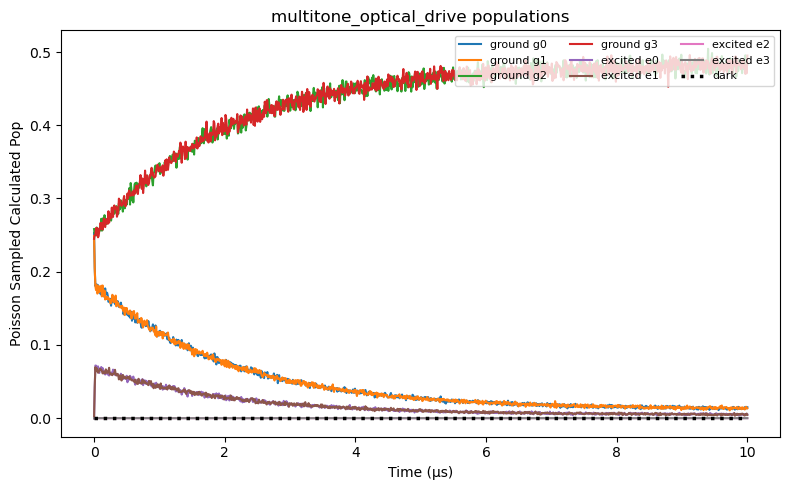

In [66]:
N=1e4
fig, ax = plt.subplots(figsize=(8, 5))
pops_poisson =np.asarray(jax.random.poisson(lam=pops*N, key=jax.random.key(20))/N )
for i in range(4):
    ax.plot(t_us, pops_poisson[i], label=f"ground g{i}")
for i in range(4):
    ax.plot(t_us, pops_poisson[4 + i], label=f"excited e{i}")
ax.plot(t_us, pops_poisson[8], color="black", linestyle=":", linewidth=2.5, label="dark")

ax.set_xlabel("Time (μs)")
ax.set_ylabel("Poisson Sampled Calculated Pop")
ax.set_title("multitone_optical_drive populations")
ax.legend(ncol=3, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

  0% |░░░░░░░░░░| [00:00<?, ?%/s]

100% |██████████| [06:00<00:00,  3.60s/%]


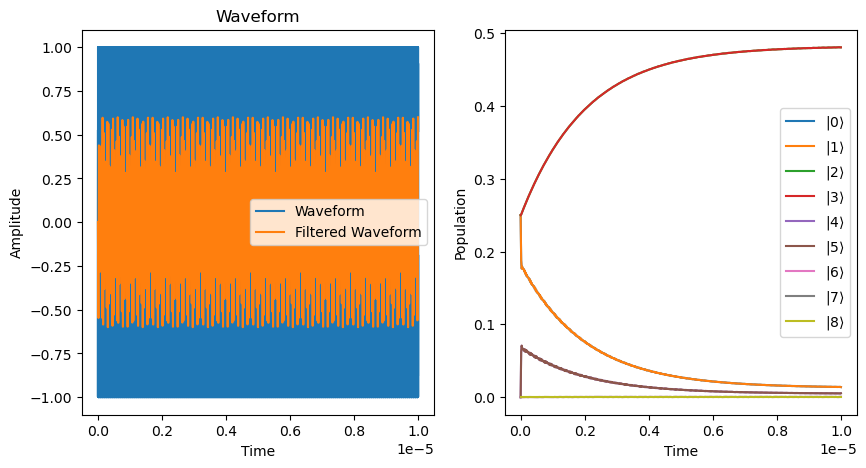

Quantum array: dims = ((9,), (9,)), bdims = (), shape = (9, 9), type = oper, impl = dense
Qarray data =
[[ 1.39362436e-02+0.00000000e+00j  0.00000000e+00+0.00000000e+00j
   1.25826580e-04-3.90824987e-04j  0.00000000e+00+0.00000000e+00j
  -2.11474148e-03+6.53401049e-03j  0.00000000e+00+0.00000000e+00j
  -8.99530916e-06+4.36576730e-06j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]
 [ 0.00000000e+00+0.00000000e+00j  1.39362436e-02+1.13417370e-14j
   0.00000000e+00+0.00000000e+00j -1.25826551e-04+3.90824996e-04j
   0.00000000e+00+0.00000000e+00j  2.11474107e-03-6.53401063e-03j
   0.00000000e+00+0.00000000e+00j  8.99530884e-06-4.36576797e-06j
   0.00000000e+00+0.00000000e+00j]
 [ 1.25826580e-04+3.90824987e-04j  0.00000000e+00+0.00000000e+00j
   4.80188839e-01+6.17314153e-14j  0.00000000e+00+0.00000000e+00j
   1.05609490e-03-4.63091415e-03j  0.00000000e+00+0.00000000e+00j
  -1.47564509e-02+2.75585899e-03j  0.00000000e+00+0.00000000e+00j
   0.00000000e+00+0.00000000e+00j]

In [67]:
downsampling = 100
pulse = AnalogPulse(
    length=10e-6,
    apodization=Apodization.COSINE,
    apodization_length=0,
    padding_length=0,
    shift=0,
    amplitude=1,
    frequency=(ph.get_ple_freqs(particle, control_state)[0] - particle.nondiff.laser_frequency) * 1e9,
    frequency_chirp=0,
    shape=Shape.SINUSOID,
    S21_correct=False,
    w_3db=2 * jnp.pi * 2e9,
    phase_offset=np.nan,
    name="",
)
pulse = CompositeWaveform([pulse])
rho0 = 0.25 * jqt.ket2dm(jqt.basis(9, 0)) + 0.25 * jqt.ket2dm(jqt.basis(9, 1)) \
     + 0.25 * jqt.ket2dm(jqt.basis(9, 2)) + 0.25 * jqt.ket2dm(jqt.basis(9, 3))
states, filter_states, populations = ph.drive_excitation_hamiltonian(
    particle,
    control_state,
    pulse,
    included_states=(0, 1, 2, 3),
    saveat_downsampling=downsampling,
    solver_options_args=(True, "Tsit5", int(1e9), 1e-4, 1e-6),
    rho0=rho0,
)

tau = make_composite_waveform_time_array(pulse, 1 / particle.nondiff.sampling_rate / 1e9, at_time=pulse.length / 2)
waveform, envelope, returned_tau = synthesize_composite_waveform(
    composite=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(returned_tau, waveform, label="Waveform")
axs[0].plot(returned_tau[::downsampling], filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(9):
    axs[1].plot(
        np.asarray(returned_tau[::downsampling]),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()
print(states[-1])

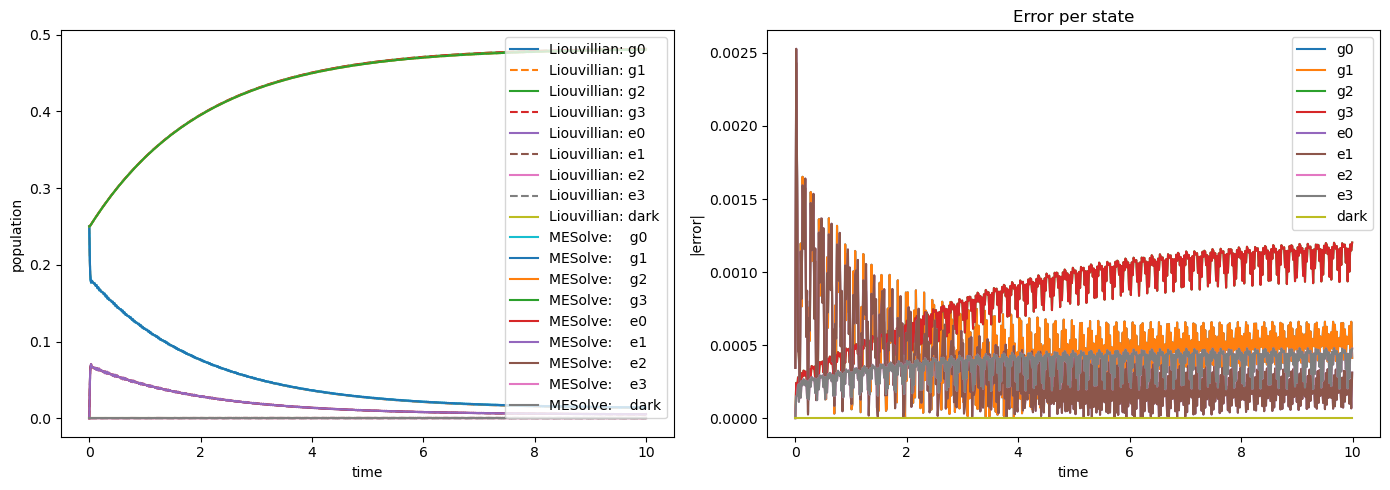

In [68]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tau = make_composite_waveform_time_array(pulse, 1 / particle.nondiff.sampling_rate / 1e9, at_time=pulse.length / 2)
waveform, envelope, returned_tau = synthesize_composite_waveform(
    composite=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
legend = ['g0', 'g1', 'g2', 'g3', 'e0', 'e1', 'e2', 'e3', 'dark']
ax = axes[0]
for i in range(9):
    ax.plot(t_us, pops_np[i], label=f"Liouvillian: {legend[i]}", linestyle=styles[i%4])
for i in range(9):
    ax.plot(
        np.asarray(returned_tau[::downsampling])*1e6,
        np.asarray(populations[i]),
        label=fr"MESolve:    {legend[i]}",
    )
# for i in range(9):
#     ax.plot(
#         np.asarray(returned_tau[::downsampling])*1e6,
#         np.asarray(populations[i]),
#         label=fr"MESolve: $|{i}\rangle$",
#     )
ax.set_xlabel("time")
ax.set_ylabel("population")
ax.legend()

tau_ds = np.asarray(returned_tau[::downsampling]*1e6)
ax2 = axes[1]
for i in range(9):
    pops_np_interp = np.interp(tau_ds, t_us, pops_np[i])
    err = np.abs(pops_np_interp - np.asarray(populations[i]))
    ax2.plot(tau_ds, err, label=legend[i])
ax2.set_xlabel("time")
ax2.set_ylabel("|error|")
ax2.set_title("Error per state")
ax2.legend()

plt.tight_layout()
plt.show()

# CPT

In [69]:
particle = particle_longitudinal_high_strain
control_state = ph.get_optimal_control_state(particle, B_target, target_dipole_operator)


[(Array(2.39625124, dtype=float64), Array(0.1, dtype=float64)), (Array(0.5, dtype=float64), Array(0.9, dtype=float64))]


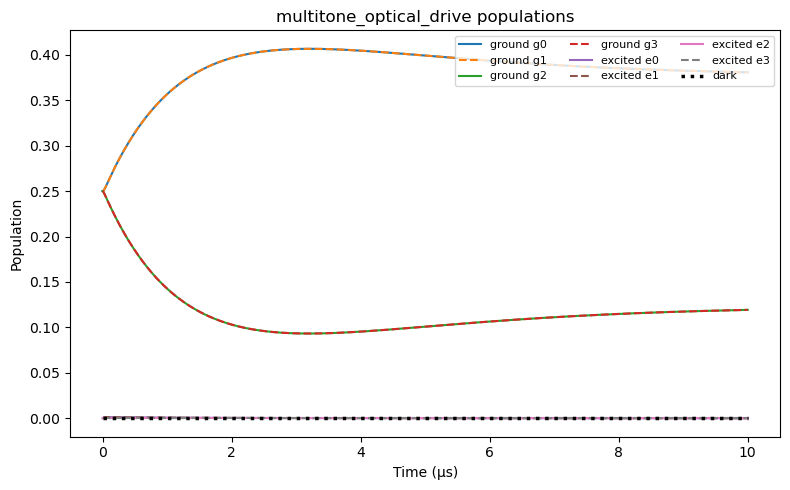

In [ ]:

E_gnd, E_exc = ph.get_state_frequencies(particle, control_state)

cpt_freqs = jnp.asarray([E_exc[0]-E_gnd[0], E_exc[0]-E_gnd[3]])

updated_laser = particle.nondiff._replace(laser_frequency=cpt_freqs[1]-0.5)
particle = particle._replace(nondiff=updated_laser)

eom_freqs = cpt_freqs - particle.nondiff.laser_frequency
eom_amps = jnp.asarray([0.1, 0.9])
print(list(zip(eom_freqs, eom_amps)))

tlist = jnp.linspace(0, 10e-6, 1000)
dimension = 2 * 4 + 1  # default included_states=(0, 1, 2, 3)
rho0 = sum(jqt.ket2dm(jqt.basis(dimension, i)) for i in range(4)) / 4.0
rhos, pops = ph.multitone_optical_drive(particle, control_state, rho0, eom_freqs, eom_amps, tlist, max_detuning=2/6)
t_us = np.asarray(tlist) * 1e6
pops_np = np.asarray(pops)

fig, ax = plt.subplots(figsize=(8, 5))

# ground_colors = plt.cm.Blues(np.linspace(0.4, 0.9, 4))
# excited_colors = plt.cm.Reds(np.linspace(0.4, 0.9, 4))
styles = ['-','--','-', '--']

for i in range(4):
    ax.plot(t_us, pops_np[i], label=f"ground g{i}", linestyle=styles[i])
for i in range(4):
    ax.plot(t_us, pops_np[4 + i], label=f"excited e{i}", linestyle=styles[i])
ax.plot(t_us, pops_np[8], color="black", linestyle=":", linewidth=2.5, label="dark")

ax.set_xlabel("Time (μs)")
ax.set_ylabel("Population")
ax.set_title("multitone_optical_drive populations")
ax.legend(ncol=3, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()


[(Array(2.39625124, dtype=float64), Array(0.1, dtype=float64)), (Array(0.5, dtype=float64), Array(0.9, dtype=float64))]


100% |██████████| [24:24<00:00, 14.64s/%]
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/floresh2/.conda/envs/zm/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


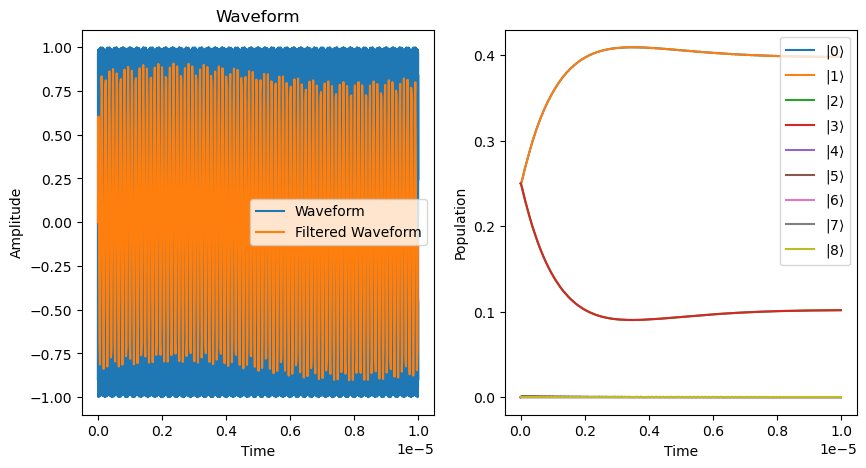

In [71]:
downsampling = 100
pulses = []
print(list(zip(eom_freqs, eom_amps)))
for f, a in zip(eom_freqs, eom_amps):
    pulses.append(AnalogPulse(
        length=10e-6,
        apodization=Apodization.COSINE,
        apodization_length=0,
        padding_length=0,
        shift=0,
        amplitude=a,
        frequency=f * 1e9,
        frequency_chirp=0,
        shape=Shape.SINUSOID,
        phase_offset=np.nan,
        name="",
    ))
pulse = CompositeWaveform(pulses)
rho0 = 0.25 * jqt.ket2dm(jqt.basis(9, 0)) + 0.25 * jqt.ket2dm(jqt.basis(9, 1)) \
     + 0.25 * jqt.ket2dm(jqt.basis(9, 2)) + 0.25 * jqt.ket2dm(jqt.basis(9, 3))
states, filter_states, populations = ph.drive_excitation_hamiltonian(
    particle,
    control_state,
    pulse,
    included_states=(0, 1, 2, 3),
    saveat_downsampling=downsampling,
    solver_options_args=(True, "Tsit5", int(1e9), 1e-7, 1e-9),
    rho0=rho0,
)

tau = make_composite_waveform_time_array(pulse, 1 / particle.nondiff.sampling_rate / 1e9, at_time=pulse.length / 2)
waveform, envelope, returned_tau = synthesize_composite_waveform(
    composite=pulse,
    tau=tau,
    at_time=pulse.length / 2,
    all_info=True,
    dphase=0.0,
)
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].plot(returned_tau, waveform, label="Waveform")
axs[0].plot(returned_tau[::downsampling], filter_states[1], label="Filtered Waveform")
axs[0].set_title("Waveform")
axs[0].set_xlabel("Time")
axs[0].set_ylabel("Amplitude")
axs[0].legend()

for i in range(9):
    axs[1].plot(
        np.asarray(returned_tau[::downsampling]),
        np.asarray(populations[i]),
        label=fr"$|{i}\rangle$",
    )

axs[1].set_xlabel("Time")
axs[1].set_ylabel("Population")
axs[1].legend()
plt.show()

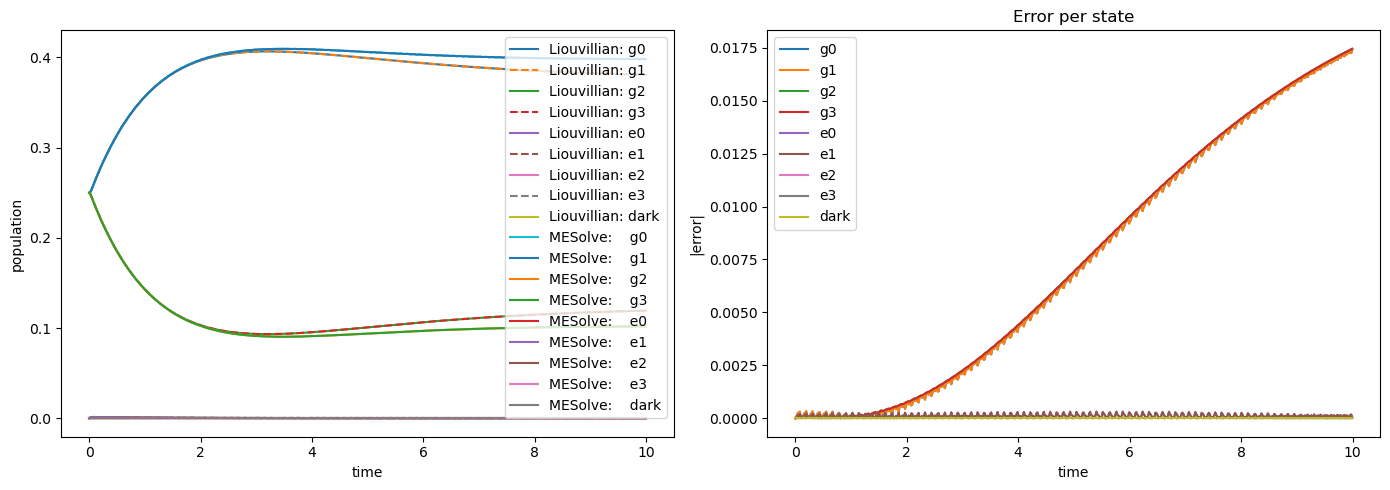

In [72]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

legend = ['g0', 'g1', 'g2', 'g3', 'e0', 'e1', 'e2', 'e3', 'dark']
ax = axes[0]
for i in range(9):
    ax.plot(t_us, pops_np[i], label=f"Liouvillian: {legend[i]}", linestyle=styles[i%4])
for i in range(9):
    ax.plot(
        np.asarray(returned_tau[::downsampling])*1e6,
        np.asarray(populations[i]),
        label=fr"MESolve:    {legend[i]}",
    )
# for i in range(9):
#     ax.plot(
#         np.asarray(returned_tau[::downsampling])*1e6,
#         np.asarray(populations[i]),
#         label=fr"MESolve: $|{i}\rangle$",
#     )
ax.set_xlabel("time")
ax.set_ylabel("population")
ax.legend()

tau_ds = np.asarray(returned_tau[::downsampling]*1e6)
ax2 = axes[1]
for i in range(9):
    pops_np_interp = np.interp(tau_ds, t_us, pops_np[i])
    err = np.abs(pops_np_interp - np.asarray(populations[i]))
    ax2.plot(tau_ds, err, label=legend[i])
ax2.set_xlabel("time")
ax2.set_ylabel("|error|")
ax2.set_title("Error per state")
ax2.legend()

plt.tight_layout()
plt.show()

# Latin Hypercube Sampling

`testing.ipynb` used Latin hypercube sampling to build a *distribution* of
`N` particles for `SnV120Distribution`. Sampling many particles is still
exactly what you want when you need an ensemble — nothing about the
particle-level refactor changes that. What changes is only the last step:
instead of passing `N`-length arrays into `SnV120Distribution(weights=...,
constants=..., ...)`, you assemble the same `N`-length arrays into one
`SnVDifferentiableParams`/`SnVNonDiffParams` pair (each leaf already has
a leading particle axis) and wrap them in `SnVParticle`/`SnVDistribution`.
Every `particle_helpers` function still only ever sees *one* particle at a
time — `jax.vmap` (or `particle.make_batched_helper`) is what runs it across
the whole ensemble.

The prior/sampling machinery below (`Prior`, `latin_hypercube`,
`sample_stratified_priors`, `repeat_for_particles`) is generic — it does not
touch `qcontrol` classes at all, so it is unchanged from `testing.ipynb`.

In [73]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Callable, Mapping

import jax
import jax.numpy as jnp
import jax.scipy.special as jsp


Array = jax.Array


# =============================================================================
# Prior specification
# =============================================================================

@dataclass(frozen=True)
class Prior:
    """
    A prior that can be generated from unit-hypercube samples.

    Parameters
    ----------
    ndim
        Number of independent U(0, 1) coordinates required by the prior.

    transform
        Function mapping an array of shape (N, ndim) to samples whose leading
        dimension is N.
    """
    ndim: int
    transform: Callable[[Array], Array]


def normal_prior(mean, std) -> Prior:
    """
    Independent normal prior over one scalar or an arbitrary array.

    Every element is stratified independently.

    Examples
    --------
    Scalar:
        normal_prior(5.0, 0.2)

    Vector:
        normal_prior(
            mean=jnp.array([1.0, 1.0, 1.0]),
            std=jnp.array([0.01, 0.02, 0.01]),
        )
    """
    mean, std = jnp.broadcast_arrays(
        jnp.asarray(mean),
        jnp.asarray(std),
    )

    output_shape = mean.shape
    ndim = mean.size

    mean_flat = mean.reshape(-1)
    std_flat = std.reshape(-1)

    def transform(u):
        # Protect ndtri from exactly 0 or 1.
        eps = jnp.finfo(u.dtype).eps
        u = jnp.clip(u, eps, 1.0 - eps)

        z = jsp.ndtri(u)

        x = (
            mean_flat[None, :]
            + std_flat[None, :] * z
        )

        return x.reshape((u.shape[0],) + output_shape)

    return Prior(
        ndim=ndim,
        transform=transform,
    )


def uniform_prior(low, high) -> Prior:
    """
    Independent uniform prior over one scalar or arbitrary array.
    """
    low, high = jnp.broadcast_arrays(
        jnp.asarray(low),
        jnp.asarray(high),
    )

    output_shape = low.shape
    ndim = low.size

    low_flat = low.reshape(-1)
    high_flat = high.reshape(-1)

    def transform(u):
        x = (
            low_flat[None, :]
            + u * (high_flat - low_flat)[None, :]
        )

        return x.reshape((u.shape[0],) + output_shape)

    return Prior(
        ndim=ndim,
        transform=transform,
    )

def loguniform_prior(low, high) -> Prior:
    log_low = jnp.log(low)
    log_high = jnp.log(high)

    def transform(u):
        return jnp.exp(
            log_low + u[:, 0] * (log_high - log_low)
        )

    return Prior(
        ndim=1,
        transform=transform,
    )

def lognormal_prior(log_mean, log_std) -> Prior:
    """
    Log-normal prior.

    `log_mean` and `log_std` specify the underlying normal distribution:

        log(X) ~ Normal(log_mean, log_std)
    """
    underlying = normal_prior(log_mean, log_std)

    def transform(u):
        return jnp.exp(underlying.transform(u))

    return Prior(
        ndim=underlying.ndim,
        transform=transform,
    )


def categorical_prior(probabilities) -> Prior:
    """
    Categorical prior using stratified inverse-CDF sampling.

    Parameters
    ----------
    probabilities : array, shape (K,)
        Probability of each categorical value 0, ..., K - 1.

    Returns
    -------
    Prior
        Samples are integer category indices.
    """
    probabilities = jnp.asarray(probabilities, dtype=float)
    probabilities = probabilities / jnp.sum(probabilities)

    cdf = jnp.cumsum(probabilities)

    def transform(u):
        q = u[:, 0]

        # Equivalent to inverse-CDF sampling.
        return jnp.sum(
            q[:, None] > cdf[None, :],
            axis=-1,
        ).astype(jnp.int32)

    return Prior(
        ndim=1,
        transform=transform,
    )


def multivariate_normal_prior(mean, covariance) -> Prior:
    """
    Correlated multivariate-normal prior.

    This should be used instead of separate normal priors when parameters have
    known covariance.

    Parameters
    ----------
    mean : array, shape (D,)
        Mean vector.

    covariance : array, shape (D, D)
        Covariance matrix.
    """
    mean = jnp.asarray(mean)
    covariance = jnp.asarray(covariance)

    ndim = mean.shape[0]

    if covariance.shape != (ndim, ndim):
        raise ValueError(
            f"Expected covariance shape {(ndim, ndim)}, "
            f"received {covariance.shape}."
        )

    chol = jnp.linalg.cholesky(covariance)

    def transform(u):
        eps = jnp.finfo(u.dtype).eps
        u = jnp.clip(u, eps, 1.0 - eps)

        # Independent stratified standard-normal coordinates.
        z = jsp.ndtri(u)

        # Introduce the requested covariance.
        return mean[None, :] + z @ chol.T

    return Prior(
        ndim=ndim,
        transform=transform,
    )


# =============================================================================
# Latin hypercube / stratified unit-cube samples
# =============================================================================

def latin_hypercube(
    key,
    n_samples: int,
    n_dimensions: int,
    *,
    jitter: bool = True,
):
    """
    Generate a randomized Latin hypercube in [0, 1]^D.

    Each dimension contains exactly one point in every interval

        [0/N, 1/N),
        [1/N, 2/N),
        ...
        [(N-1)/N, 1).

    The intervals are shuffled independently in each dimension.

    Parameters
    ----------
    key
        JAX random key.

    n_samples
        Number of particles.

    n_dimensions
        Number of scalar dimensions.

    jitter
        If True, choose a random point inside each stratum.

        If False, use each stratum midpoint. The dimensions are still
        independently permuted.

    Returns
    -------
    jax.Array, shape (n_samples, n_dimensions)
        Latin-hypercube points.
    """
    key_jitter, key_permutations = jax.random.split(key)

    strata = jnp.arange(n_samples, dtype=jnp.float64)

    if jitter:
        offsets = jax.random.uniform(
            key_jitter,
            shape=(n_samples, n_dimensions),
            dtype=jnp.float64,
        )
    else:
        offsets = jnp.full(
            (n_samples, n_dimensions),
            0.5,
            dtype=jnp.float64,
        )

    # Before permutation, every column traverses its N strata in order.
    u = (
        strata[:, None] + offsets
    ) / n_samples

    # Shuffle each dimension independently. Without this step, all dimensions
    # would have nearly perfect artificial positive correlation.
    permutation_keys = jax.random.split(
        key_permutations,
        n_dimensions,
    )

    u = jax.vmap(
        lambda k, column: jax.random.permutation(k, column),
        in_axes=(0, 1),
        out_axes=1,
    )(
        permutation_keys,
        u,
    )

    return u


# =============================================================================
# Sample a collection of priors
# =============================================================================

def sample_stratified_priors(
    key,
    n_samples: int,
    priors: Mapping[str, Prior],
    *,
    jitter: bool = True,
):
    """
    Sample multiple priors using one Latin hypercube.

    Parameters
    ----------
    key
        JAX random key.

    n_samples
        Number of particles.

    priors
        Dictionary mapping parameter names to Prior objects.

    jitter
        Randomize positions within each stratum.

    Returns
    -------
    samples : dict
        Dictionary mapping parameter names to sampled arrays.

        Every returned array has leading dimension `n_samples`.

    weights : jax.Array, shape (n_samples,)
        Uniform weights equal to 1 / n_samples.
    """
    total_dimensions = sum(
        prior.ndim
        for prior in priors.values()
    )

    u = latin_hypercube(
        key,
        n_samples=n_samples,
        n_dimensions=total_dimensions,
        jitter=jitter,
    )

    samples = {}

    start = 0

    for name, prior in priors.items():
        stop = start + prior.ndim

        samples[name] = prior.transform(
            u[:, start:stop]
        )

        start = stop

    weights = jnp.full(
        n_samples,
        1.0 / n_samples,
        dtype=jnp.float64,
    )

    return samples, weights


# =============================================================================
# Convenience helper for fixed SnV parameters
# =============================================================================

def repeat_for_particles(value, n_samples):
    """
    Broadcast one fixed parameter over the particle dimension.

    Examples
    --------
    scalar:
        4.5
        -> shape (N,)

    vector:
        [1, 2]
        -> shape (N, 2)

    matrix:
        shape (3, 3)
        -> shape (N, 3, 3)
    """
    value = jnp.asarray(value)

    return jnp.broadcast_to(
        value,
        (n_samples,) + value.shape,
    )

## Example: sampling an `SnVDistribution`

Only the parameters below have priors; everything else is held fixed across
the ensemble with `repeat_for_particles`, exactly like `testing.ipynb`. Two
small differences from the original priors dict:

- The key `"dipole_crystal_axes"` is renamed to `"dipole_crystal_axis_idx"`
  to match the actual `SnVNonDiffParams` field it fills — the original name
  was a bit misleading (it samples a categorical *index*, not the fixed
  `(4, 3)` axis table).
- `testing.ipynb`'s final `SnV120Distribution(...)` call was missing several
  required fields (`resonant_pump_phase`, `resonant_pump_pdl`,
  `mode_field_orientation`, `transmission_out_diamond`,
  `reflection_from_pic`) and would have raised `TypeError: missing ...
  positional argument` if actually run. These are filled in below with the
  same fixed values used by `get_basic_particle` earlier in this notebook.

In [74]:
N = 3000
key = jax.random.PRNGKey(42)


# -------------------------------------------------------------------------
# Define ONLY the quantities for which you have uncertainty.
#
# The numerical values below are examples. Replace them with your actual
# measured / inferred priors.
# -------------------------------------------------------------------------
magnet_mag_f = 0.5
magnet_rot_f = 0.5
priors = {
    # One scalar alpha per particle.
    "alpha": normal_prior(
        mean=0,
        std=0.02,
    ),

    "beta": normal_prior(
        mean=0,
        std=0.005,
    ),

    "alpha_exc": normal_prior(
        mean=0,
        std=0.02,
    ),

    "beta_exc": normal_prior(
        mean=0,
        std=0.005,
    ),
    "hyperfine_neighbor_idx": categorical_prior(
        jnp.array([
            1.0/3,
            1.0/3,
            1.0/3,
            0,
        ])
    ),
    # Three separate magnet calibration factors.
    #
    # Output:
    #     (N, 3)
    "magnet_unit_magnitude": multivariate_normal_prior(
        mean=jnp.array([
            1.00,
            1.00,
            1.00,
        ]),
        covariance=0.01*jnp.array([
            [1, magnet_mag_f, magnet_mag_f],
            [magnet_mag_f, 1, magnet_mag_f],
            [magnet_mag_f, magnet_mag_f, 1]
        ]),
    ),

    "magnet_axes_rotations": multivariate_normal_prior(
        mean=jnp.zeros(9),
        covariance=0.01*jnp.array([
            [1, 0, 0, magnet_rot_f, 0, 0, magnet_rot_f, 0, 0],
            [0, 1, 0, 0, magnet_rot_f, 0, 0, magnet_rot_f, 0],
            [0, 0, 1, 0, 0, magnet_rot_f, 0, 0, magnet_rot_f],
            [magnet_rot_f, 0, 0, 1, 0, 0, magnet_rot_f, 0, 0],
            [0, magnet_rot_f, 0, 0, 1, 0, 0, magnet_rot_f, 0],
            [0, 0, magnet_rot_f, 0, 0, 1, 0, 0, magnet_rot_f],
            [magnet_rot_f, 0, 0, magnet_rot_f, 0, 0, 1, 0, 0],
            [0, magnet_rot_f, 0, 0, magnet_rot_f, 0, 0, 1, 0],
            [0, 0, magnet_rot_f, 0, 0, magnet_rot_f, 0, 0, 1],
        ]),
    ),

    # One of four possible <111> orientations.
    #
    # Output:
    #     (N,)
    "dipole_crystal_axis_idx": categorical_prior(
        jnp.array([
            0.25,
            0.25,
            0.25,
            0.25,
        ])
    ),

    # Positive lifetime parameter.
    #
    # This example assumes log(lifetime) is normally distributed.
    "excited_state_lifetime": lognormal_prior(
        log_mean=jnp.log(4.5),
        log_std=0.05,
    ),

    "debye_waller_factor": normal_prior(
        mean=0.60,
        std=0.03,
    ),

    "quantum_efficiency": normal_prior(
        mean=0.90,
        std=0.02,
    ),
    "optical_transmission": loguniform_prior(
        low=1e-5,
        high=1e-3,
    ),
    "dark_count_rate": normal_prior(
        mean=300,
        std=10,
    ),
    "resonant_pump_coupling_rate": loguniform_prior(
        low=1e-3,
        high=5e-2,
    ),
    "resonant_pump_polarization": uniform_prior(
        low=0,
        high=2*jnp.pi,
    ),
    "eom_vpi_ratio": normal_prior(
        mean=0.6,
        std=0.1,
    ),
    "eom_vpi_bandwidth": normal_prior(
        mean=1.5,
        std=.15,
    ),
    "mw_B_orientation": uniform_prior(
        low=[0, 0],
        high=[jnp.pi/2, 2*jnp.pi],
    ),
    "mw_B_magnitude": normal_prior(
        mean=0.5,
        std=0.1,
    ),
    "mw_B_bandwidth": normal_prior(
        mean=1.5,
        std=.15,
    ),
    "spectral_diffusion_rate": uniform_prior(
        low=0,
        high=0,
    ),
    "polarization_drift_rate": uniform_prior(
        low=0,
        high=0,
    ),
    "resonant_pump_coupling_drift_rate": uniform_prior(
        low=0,
        high=0,
    ),
}


samples, weights = sample_stratified_priors(
    key,
    n_samples=N,
    priors=priors,
    jitter=True,
)


# -------------------------------------------------------------------------
# Inspect the result.
# -------------------------------------------------------------------------

print("weights:", weights.shape)
print("sum(weights):", weights.sum())

for name, value in samples.items():
    print(
        f"{name:30s}",
        value.shape,
    )

weights: (3000,)
sum(weights): 1.0
alpha                          (3000,)
beta                           (3000,)
alpha_exc                      (3000,)
beta_exc                       (3000,)
hyperfine_neighbor_idx         (3000,)
magnet_unit_magnitude          (3000, 3)
magnet_axes_rotations          (3000, 9)
dipole_crystal_axis_idx        (3000,)
excited_state_lifetime         (3000,)
debye_waller_factor            (3000,)
quantum_efficiency             (3000,)
optical_transmission           (3000,)
dark_count_rate                (3000,)
resonant_pump_coupling_rate    (3000,)
resonant_pump_polarization     (3000,)
eom_vpi_ratio                  (3000,)
eom_vpi_bandwidth              (3000,)
mw_B_orientation               (3000, 2)
mw_B_magnitude                 (3000,)
mw_B_bandwidth                 (3000,)
spectral_diffusion_rate        (3000,)
polarization_drift_rate        (3000,)
resonant_pump_coupling_drift_rate (3000,)


In [75]:
# -------------------------------------------------------------------------
# Assemble the sampled (and fixed) per-particle arrays into one
# SnVDifferentiableParams / SnVNonDiffParams pair, each leaf already carrying
# the leading particle axis, then wrap them as an SnVDistribution.
#
# This plays the role of the old `SnV120Distribution(weights=..., constants=...,
# ...)` call: every field the old distribution stored under `constants`
# (shared across all members) is now `repeat_for_particles`-broadcast onto
# the per-particle `SnVNonDiffParams`.
# -------------------------------------------------------------------------

diffable = SnVDifferentiableParams(
    magnet_unit_magnitude=samples["magnet_unit_magnitude"],           # (N, 3)
    magnet_axes_rotations=jnp.reshape(samples["magnet_axes_rotations"], (N, 3, 3)),
    strain_params=jnp.stack(
        [
            jnp.zeros(N),           # zpl_shift
            samples["alpha"],
            samples["beta"],
            samples["alpha_exc"],
            samples["beta_exc"],
        ],
        axis=-1,
    ),                                                                 # (N, 5)
    # optical_transmission=samples["optical_transmission"],
    dark_count_rate=samples["dark_count_rate"],

    # Resonant pump coupling
    resonant_pump_coupling_rate=samples["resonant_pump_coupling_rate"],
    resonant_pump_pdl=repeat_for_particles(1.0, N),
    resonant_pump_polarization=samples["resonant_pump_polarization"],
    resonant_pump_phase=repeat_for_particles(0.0, N),
    mode_field_orientation=repeat_for_particles(
        jnp.asarray([[0.0, 0.0], [0.5 * jnp.pi, 0.5 * jnp.pi]]), N
    ),
    transmission_out_diamond=repeat_for_particles(jnp.ones(2), N),
    reflection_from_pic=repeat_for_particles(jnp.zeros(2), N),

    eom_vpi_ratio=samples["eom_vpi_ratio"],
    eom_vpi_bandwidth=samples["eom_vpi_bandwidth"],

    # Transmission line dynamic B field
    mw_B_orientation=samples["mw_B_orientation"],
    mw_B_magnitude=samples["mw_B_magnitude"],
    mw_B_bandwidth=samples["mw_B_bandwidth"],

    # Drift and diffusion
    spectral_diffusion_rate=samples["spectral_diffusion_rate"],
    polarization_drift_rate=samples["polarization_drift_rate"],
    resonant_pump_coupling_drift_rate=samples["resonant_pump_coupling_drift_rate"],
)

nondiff = SnVNonDiffParams(
    dipole_crystal_axis_idx=samples["dipole_crystal_axis_idx"],
    hyperfine_neighbor_idx=samples["hyperfine_neighbor_idx"],
    excited_state_lifetime=samples["excited_state_lifetime"],
    debye_waller_factor=samples["debye_waller_factor"],
    quantum_efficiency=samples["quantum_efficiency"],
    laser_frequency=repeat_for_particles(laser_frequency, N),
    diamond_lattice_100_orientation=repeat_for_particles(diamond_lattice_100_orientation, N),
    diamond_lattice_011_orientation=repeat_for_particles(diamond_lattice_011_orientation, N),
    nominal_magnet_axes=repeat_for_particles(nominal_magnet_axes, N),
    sampling_rate=repeat_for_particles(sampling_rate, N),
    mu_B_GHz_per_T=repeat_for_particles(13.996, N),
    dipole_crystal_axes=repeat_for_particles(dipole_crystal_axes, N),
)

sampled_ensemble = SnVDistribution(
    particles=SnVParticle(diffable=diffable, nondiff=nondiff),
    weights=weights,
)
print("ensemble size:", sampled_ensemble.size)

ensemble size: 3000


## Running single-particle helpers across the ensemble

Every `particle_helpers` function still only understands one particle. Two
`jax.vmap` patterns cover everything `SnV120Distribution`'s `idx`-batched
methods used to do:

- **Per-particle optimal controls** (`control_state=None` in the old API):
  `jax.vmap(particle_helpers.get_optimal_control_state, in_axes=(0, None, None))`
  computes each particle's own optimal magnet/waveplate settings, and then
  `in_axes=(0, 0)` runs a helper with each particle paired to its own control
  state.
- **One shared control state for every particle** (an explicit
  `control_state` in the old API): `particle.make_batched_helper` fixes
  `in_axes=(0, None)` for exactly this case.

Extracting one particle with `SnVDistribution.particle(index)` hands you back
a plain `SnVParticle` — the same object `get_basic_particle` builds — so
every single-particle example earlier in this notebook applies unchanged.

dipole_B_GHz: mean 1.7212793986352388 std 2.94659130828976e-16


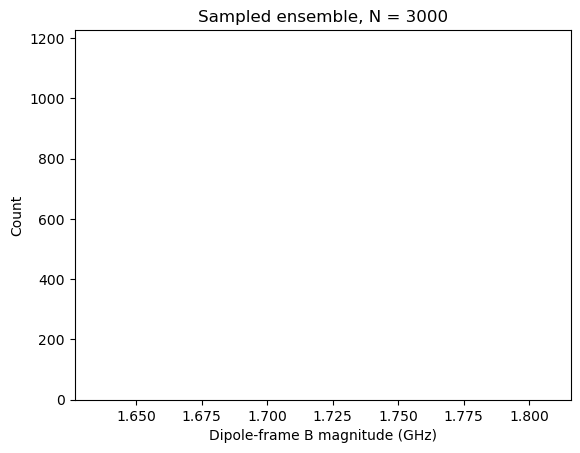

dipole_B_GHz under one shared control state: mean 2.185811871371825 std 0.2177404048378788
Example particle EMR frequencies: [2.41219977 1.43556138]


In [76]:
# Per-particle optimal controls, vmapped across the whole ensemble.
control_states = jax.vmap(
    ph.get_optimal_control_state, in_axes=(0, None, None)
)(sampled_ensemble.particles, B_target, target_dipole_operator)

dipole_B_GHz = jax.vmap(ph.get_dipole_B_GHz, in_axes=(0, 0))(
    sampled_ensemble.particles, control_states
)
print("dipole_B_GHz: mean", jnp.mean(dipole_B_GHz), "std", jnp.std(dipole_B_GHz))

plt.hist(np.asarray(dipole_B_GHz), bins=50)
plt.xlabel("Dipole-frame B magnitude (GHz)")
plt.ylabel("Count")
plt.title(f"Sampled ensemble, N = {sampled_ensemble.size}")
plt.show()

# One shared control state for every particle, using make_batched_helper.
shared_control_state = ph.get_optimal_control_state(
    sampled_ensemble.particle(0), B_target, target_dipole_operator
)
dipole_B_GHz_shared_controls = make_batched_helper(ph.get_dipole_B_GHz)(
    sampled_ensemble.particles, shared_control_state
)
print(
    "dipole_B_GHz under one shared control state: mean",
    jnp.mean(dipole_B_GHz_shared_controls),
    "std",
    jnp.std(dipole_B_GHz_shared_controls),
)

# Extract a single particle and fall back to the plain single-particle API
# used throughout the rest of this notebook.
example_particle = sampled_ensemble.particle(0)
example_control_state = ph.get_optimal_control_state(
    example_particle, B_target, target_dipole_operator
)
print("Example particle EMR frequencies:", ph.get_emr_freqs(example_particle, example_control_state))